In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import plotly.express as px
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression,LassoCV
from sklearn.feature_selection import RFE,RFECV
from sklearn.model_selection import StratifiedKFold,KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score

In [2]:
stock = yf.Ticker("NFLX")

In [3]:
# df = stock.history(period="5y",interval='1d')

In [4]:
df = pd.read_csv('/home/alen_sunny/Desktop/Week-18-Regression-Classification project/Netflix_data.csv')

In [5]:
# df.to_csv('Netflix_data.csv')

In [6]:
df.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,target
0,0,2020-09-04 09:30:00+05:30,520.179993,527.359985,485.980011,516.049988,8270100,0.0,0.0,2020,9,4,1
1,1,2020-09-08 09:30:00+05:30,498.399994,522.000000,495.000000,507.019989,5572700,0.0,0.0,2020,9,8,1
2,2,2020-09-09 09:30:00+05:30,519.210022,520.000000,492.570007,500.190002,6848100,0.0,0.0,2020,9,9,1
3,3,2020-09-10 09:30:00+05:30,503.350006,506.290009,478.839996,480.670013,6240200,0.0,0.0,2020,9,10,0
4,4,2020-09-11 09:30:00+05:30,486.489990,493.730011,476.809998,482.029999,5035200,0.0,0.0,2020,9,11,1


In [7]:
df.columns

Index(['Unnamed: 0', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
       'Dividends', 'Stock Splits', 'year', 'month', 'day', 'target'],
      dtype='object')

In [8]:
df=df.drop(['Unnamed: 0'],axis=1)

In [9]:
df.shape

(1254, 12)

In [10]:
df['Stock Splits'].value_counts()

Stock Splits
0.0    1254
Name: count, dtype: int64

In [11]:
df.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,target
1249,2025-08-27 09:30:00+05:30,1223.609985,1229.209961,1213.000000,1223.500000,1664500,0.0,0.0,2025,8,27,0
1250,2025-08-28 09:30:00+05:30,1222.790039,1237.890015,1214.270020,1231.449951,1950300,0.0,0.0,2025,8,28,1
1251,2025-08-29 09:30:00+05:30,1227.969971,1228.790039,1201.150024,1208.250000,3209800,0.0,0.0,2025,8,29,0
1252,2025-09-02 09:30:00+05:30,1197.000000,1215.400024,1182.800049,1214.109985,2303300,0.0,0.0,2025,9,2,0
1253,2025-09-03 09:30:00+05:30,1205.140015,1227.000000,1203.380005,1226.180054,2466400,0.0,0.0,2025,9,3,0


In [12]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'year', 'month', 'day', 'target'],
      dtype='object')

In [13]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'year', 'month', 'day', 'target'],
      dtype='object')

In [14]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,target
0,2020-09-04 09:30:00+05:30,520.179993,527.359985,485.980011,516.049988,8270100,0.0,0.0,2020,9,4,1
1,2020-09-08 09:30:00+05:30,498.399994,522.000000,495.000000,507.019989,5572700,0.0,0.0,2020,9,8,1
2,2020-09-09 09:30:00+05:30,519.210022,520.000000,492.570007,500.190002,6848100,0.0,0.0,2020,9,9,1
3,2020-09-10 09:30:00+05:30,503.350006,506.290009,478.839996,480.670013,6240200,0.0,0.0,2020,9,10,0
4,2020-09-11 09:30:00+05:30,486.489990,493.730011,476.809998,482.029999,5035200,0.0,0.0,2020,9,11,1


In [15]:
df['Date'].dtype

dtype('O')

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [17]:
df['Date'].dtype

datetime64[ns, UTC+05:30]

In [18]:
df['year'] = df['Date'].dt.year
df['month'] =df['Date'].dt.month
df['day'] = df['Date'].dt.day

In [19]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,target
0,2020-09-04 09:30:00+05:30,520.179993,527.359985,485.980011,516.049988,8270100,0.0,0.0,2020,9,4,1
1,2020-09-08 09:30:00+05:30,498.399994,522.000000,495.000000,507.019989,5572700,0.0,0.0,2020,9,8,1
2,2020-09-09 09:30:00+05:30,519.210022,520.000000,492.570007,500.190002,6848100,0.0,0.0,2020,9,9,1
3,2020-09-10 09:30:00+05:30,503.350006,506.290009,478.839996,480.670013,6240200,0.0,0.0,2020,9,10,0
4,2020-09-11 09:30:00+05:30,486.489990,493.730011,476.809998,482.029999,5035200,0.0,0.0,2020,9,11,1


In [20]:
# Convert to UTC first, then to India timezone
df['Date'] = df['Date'].dt.tz_convert('Asia/Kolkata')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype                       
---  ------        --------------  -----                       
 0   Date          1254 non-null   datetime64[ns, Asia/Kolkata]
 1   Open          1254 non-null   float64                     
 2   High          1254 non-null   float64                     
 3   Low           1254 non-null   float64                     
 4   Close         1254 non-null   float64                     
 5   Volume        1254 non-null   int64                       
 6   Dividends     1254 non-null   float64                     
 7   Stock Splits  1254 non-null   float64                     
 8   year          1254 non-null   int32                       
 9   month         1254 non-null   int32                       
 10  day           1254 non-null   int32                       
 11  target        1254 non-null   int64                     

In [22]:
df['Date']

0      2020-09-04 09:30:00+05:30
1      2020-09-08 09:30:00+05:30
2      2020-09-09 09:30:00+05:30
3      2020-09-10 09:30:00+05:30
4      2020-09-11 09:30:00+05:30
                  ...           
1249   2025-08-27 09:30:00+05:30
1250   2025-08-28 09:30:00+05:30
1251   2025-08-29 09:30:00+05:30
1252   2025-09-02 09:30:00+05:30
1253   2025-09-03 09:30:00+05:30
Name: Date, Length: 1254, dtype: datetime64[ns, Asia/Kolkata]

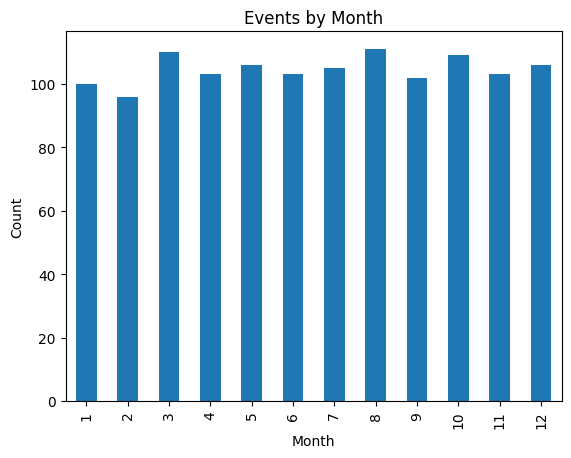

In [23]:
df['month'].value_counts().sort_index().plot(kind='bar')
plt.title('Events by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

In [24]:
df['target'] = np.zeros(len(df),dtype=int)

for i  in range(len(df['Close'])-1):
    if df['Close'].iloc[i] >=df['Close'].iloc[i+1]:
        df.loc[df.index[i],'target']=1
    else:
        df.loc[df.index[i],'target'] =0

In [25]:
df['target'].value_counts()

target
0    651
1    603
Name: count, dtype: int64

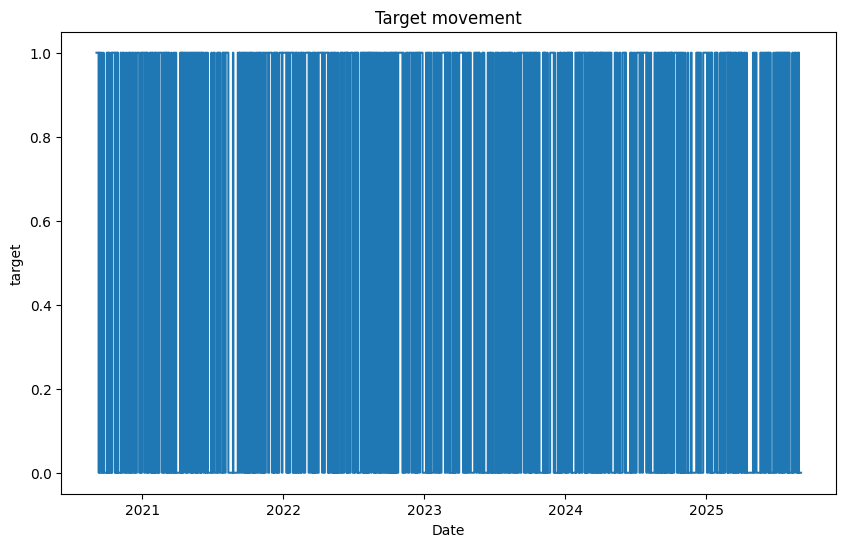

In [26]:
plt.figure(figsize=(10,6))
plt.plot(df['Date'],df['target'],drawstyle='steps-mid')
plt.title('Target movement')
plt.xlabel('Date')
plt.ylabel('target')
plt.show()

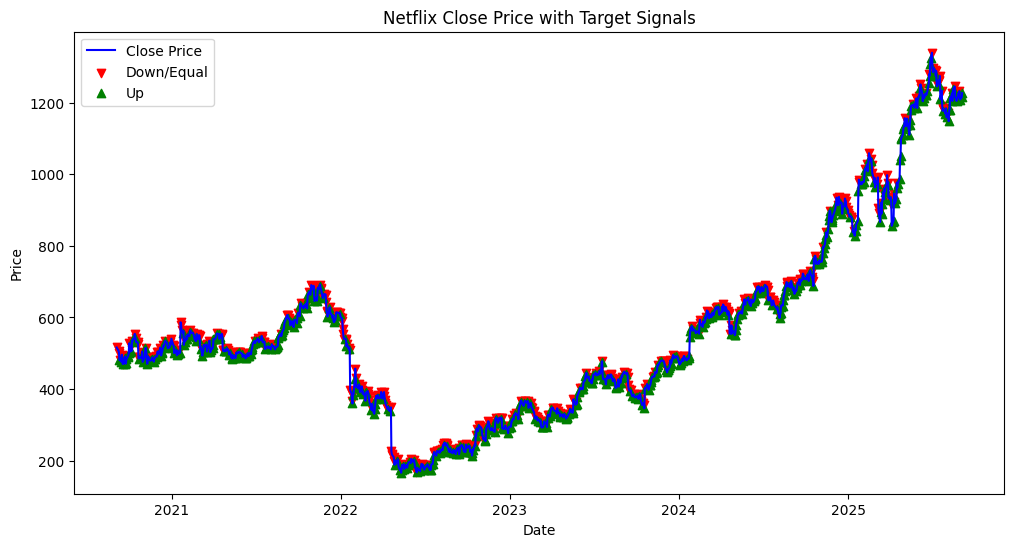

In [27]:
plt.figure(figsize=(12, 6))

# Plot stock price
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')

# Highlight target=1 points
plt.scatter(df['Date'][df['target']==1], 
            df['Close'][df['target']==1], 
            color='red', marker='v', label='Down/Equal')

# Highlight target=0 points
plt.scatter(df['Date'][df['target']==0], 
            df['Close'][df['target']==0], 
            color='green', marker='^', label='Up')

plt.title("Netflix Close Price with Target Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


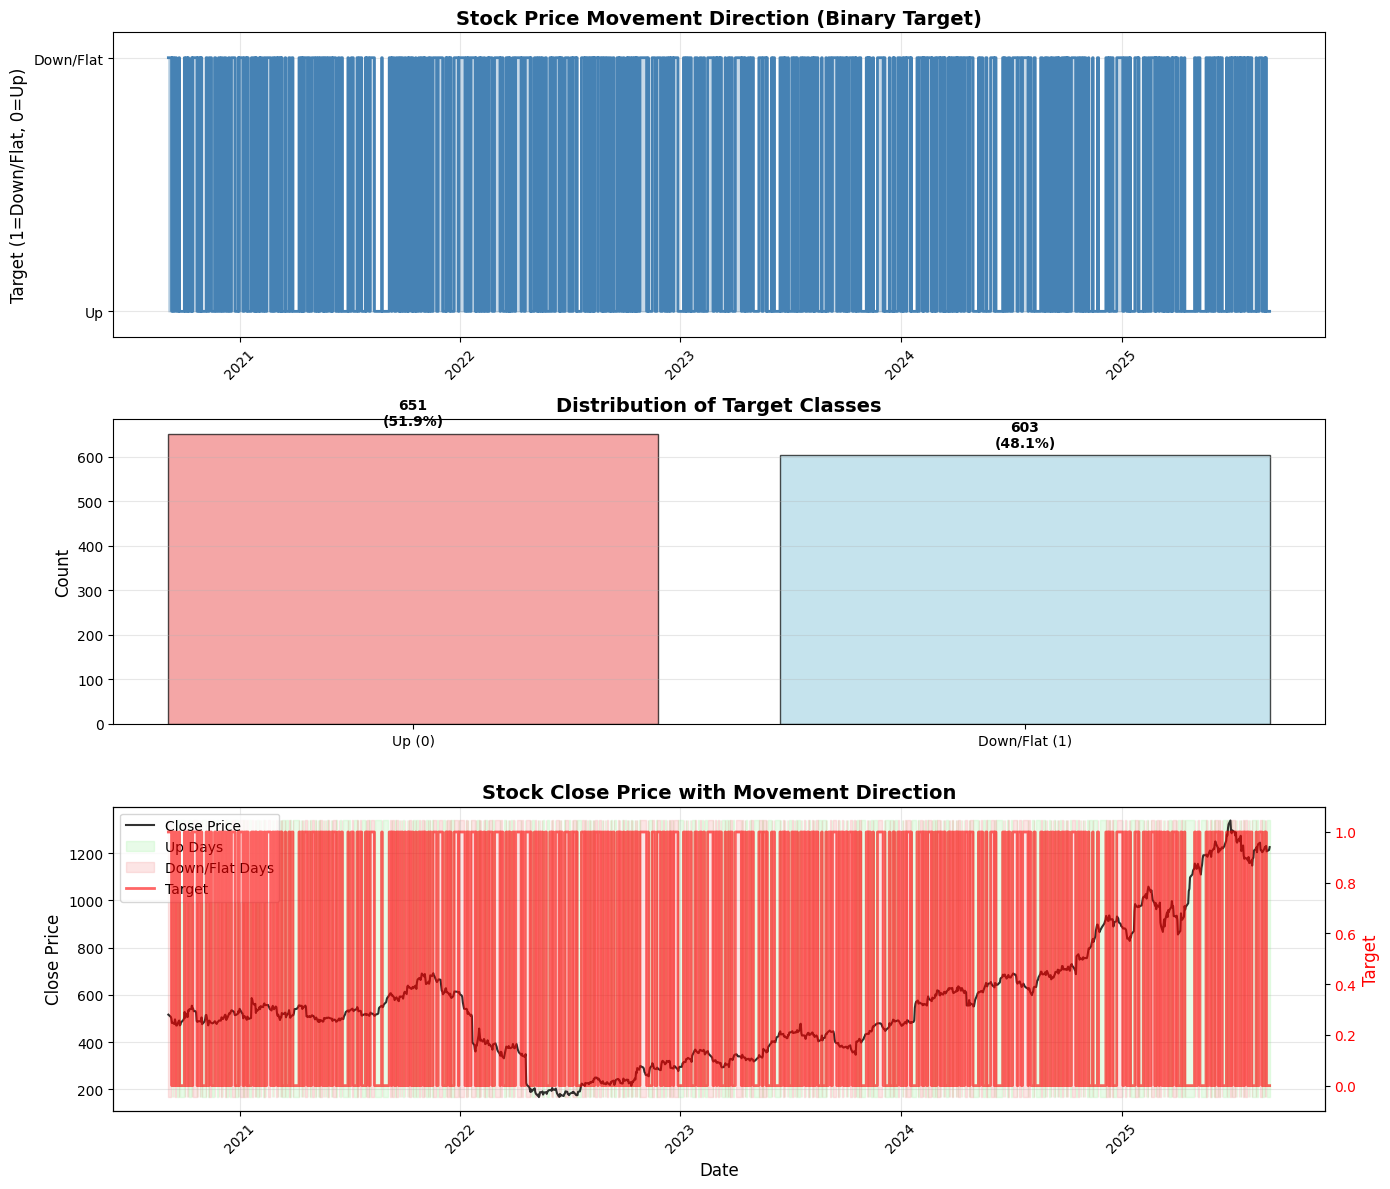

Target Distribution:
Up days (0): 651 (51.9%)
Down/Flat days (1): 603 (48.1%)
Total samples: 1254

Streak Analysis:
Max consecutive up days: 11
Max consecutive down/flat days: 8


In [28]:
# Create enhanced visualization
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Step plot with better styling
ax1.plot(df['Date'], df['target'], drawstyle='steps-mid', linewidth=2, color='steelblue')
ax1.fill_between(df['Date'], df['target'], step='mid', alpha=0.3, color='steelblue')
ax1.set_title('Stock Price Movement Direction (Binary Target)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Target (1=Down/Flat, 0=Up)', fontsize=12)
ax1.set_ylim(-0.1, 1.1)
ax1.grid(True, alpha=0.3)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Up', 'Down/Flat'])

# Plot 2: Histogram of target distribution
target_counts = df['target'].value_counts()
colors = ['lightcoral', 'lightblue']
bars = ax2.bar(['Up (0)', 'Down/Flat (1)'], target_counts.sort_index(), 
               color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax2.set_title('Distribution of Target Classes', fontsize=14, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12)

# Add percentage labels on bars
total = len(df)
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / total) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height + total*0.01,
             f'{height}\n({percentage:.1f}%)', ha='center', va='bottom', fontweight='bold')

ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Close price with target overlay
ax3_twin = ax3.twinx()

# Plot close price
line1 = ax3.plot(df['Date'], df['Close'], color='black', linewidth=1.5, alpha=0.8, label='Close Price')

# Color-code the background based on target
up_mask = df['target'] == 0
down_mask = df['target'] == 1

if up_mask.any():
    ax3.fill_between(df['Date'], df['Close'].min(), df['Close'].max(), 
                     where=up_mask, color='lightgreen', alpha=0.2, step='mid', label='Up Days')
if down_mask.any():
    ax3.fill_between(df['Date'], df['Close'].min(), df['Close'].max(), 
                     where=down_mask, color='lightcoral', alpha=0.2, step='mid', label='Down/Flat Days')

ax3.set_title('Stock Close Price with Movement Direction', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Close Price', fontsize=12)
ax3.grid(True, alpha=0.3)

# Target on right y-axis
line2 = ax3_twin.plot(df['Date'], df['target'], drawstyle='steps-mid', 
                      color='red', alpha=0.6, linewidth=2, label='Target')
ax3_twin.set_ylabel('Target', fontsize=12, color='red')
ax3_twin.set_ylim(-0.1, 1.1)
ax3_twin.tick_params(axis='y', labelcolor='red')

# Combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Format dates on x-axis
for ax in [ax1, ax3]:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print some statistics
print("Target Distribution:")
print(f"Up days (0): {target_counts[0]} ({target_counts[0]/total*100:.1f}%)")
print(f"Down/Flat days (1): {target_counts[1]} ({target_counts[1]/total*100:.1f}%)")
print(f"Total samples: {total}")

# Optional: Calculate some additional metrics
if len(df) > 1:
    consecutive_ups = 0
    consecutive_downs = 0
    max_consecutive_ups = 0
    max_consecutive_downs = 0
    current_streak = 1
    
    for i in range(1, len(df)):
        if df['target'].iloc[i] == df['target'].iloc[i-1]:
            current_streak += 1
        else:
            if df['target'].iloc[i-1] == 0:
                max_consecutive_ups = max(max_consecutive_ups, current_streak)
            else:
                max_consecutive_downs = max(max_consecutive_downs, current_streak)
            current_streak = 1
    
    # Don't forget the last streak
    if df['target'].iloc[-1] == 0:
        max_consecutive_ups = max(max_consecutive_ups, current_streak)
    else:
        max_consecutive_downs = max(max_consecutive_downs, current_streak)
    
    print(f"\nStreak Analysis:")
    print(f"Max consecutive up days: {max_consecutive_ups}")
    print(f"Max consecutive down/flat days: {max_consecutive_downs}")

In [29]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,target
0,2020-09-04 09:30:00+05:30,520.179993,527.359985,485.980011,516.049988,8270100,0.0,0.0,2020,9,4,1
1,2020-09-08 09:30:00+05:30,498.399994,522.000000,495.000000,507.019989,5572700,0.0,0.0,2020,9,8,1
2,2020-09-09 09:30:00+05:30,519.210022,520.000000,492.570007,500.190002,6848100,0.0,0.0,2020,9,9,1
3,2020-09-10 09:30:00+05:30,503.350006,506.290009,478.839996,480.670013,6240200,0.0,0.0,2020,9,10,0
4,2020-09-11 09:30:00+05:30,486.489990,493.730011,476.809998,482.029999,5035200,0.0,0.0,2020,9,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-08-27 09:30:00+05:30,1223.609985,1229.209961,1213.000000,1223.500000,1664500,0.0,0.0,2025,8,27,0
1250,2025-08-28 09:30:00+05:30,1222.790039,1237.890015,1214.270020,1231.449951,1950300,0.0,0.0,2025,8,28,1
1251,2025-08-29 09:30:00+05:30,1227.969971,1228.790039,1201.150024,1208.250000,3209800,0.0,0.0,2025,8,29,0
1252,2025-09-02 09:30:00+05:30,1197.000000,1215.400024,1182.800049,1214.109985,2303300,0.0,0.0,2025,9,2,0


In [30]:
df.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,target
1249,2025-08-27 09:30:00+05:30,1223.609985,1229.209961,1213.000000,1223.500000,1664500,0.0,0.0,2025,8,27,0
1250,2025-08-28 09:30:00+05:30,1222.790039,1237.890015,1214.270020,1231.449951,1950300,0.0,0.0,2025,8,28,1
1251,2025-08-29 09:30:00+05:30,1227.969971,1228.790039,1201.150024,1208.250000,3209800,0.0,0.0,2025,8,29,0
1252,2025-09-02 09:30:00+05:30,1197.000000,1215.400024,1182.800049,1214.109985,2303300,0.0,0.0,2025,9,2,0
1253,2025-09-03 09:30:00+05:30,1205.140015,1227.000000,1203.380005,1226.180054,2466400,0.0,0.0,2025,9,3,0


## About the dataset
Date - specifies trading date

Open - opening price

High - maximum price during the day

Low - minimum price during the day

Close - close price adjusted for splits

Volume - the number of shares that changed hands during a given day


# Asking the basic questions

### How big is data ?

In [31]:
df.shape

(1254, 12)

### How does the data look like ?


In [32]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,day,target
0,2020-09-04 09:30:00+05:30,520.179993,527.359985,485.980011,516.049988,8270100,0.0,0.0,2020,9,4,1
1,2020-09-08 09:30:00+05:30,498.399994,522.000000,495.000000,507.019989,5572700,0.0,0.0,2020,9,8,1
2,2020-09-09 09:30:00+05:30,519.210022,520.000000,492.570007,500.190002,6848100,0.0,0.0,2020,9,9,1
3,2020-09-10 09:30:00+05:30,503.350006,506.290009,478.839996,480.670013,6240200,0.0,0.0,2020,9,10,0
4,2020-09-11 09:30:00+05:30,486.489990,493.730011,476.809998,482.029999,5035200,0.0,0.0,2020,9,11,1


### What is the data type of col?

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype                       
---  ------        --------------  -----                       
 0   Date          1254 non-null   datetime64[ns, Asia/Kolkata]
 1   Open          1254 non-null   float64                     
 2   High          1254 non-null   float64                     
 3   Low           1254 non-null   float64                     
 4   Close         1254 non-null   float64                     
 5   Volume        1254 non-null   int64                       
 6   Dividends     1254 non-null   float64                     
 7   Stock Splits  1254 non-null   float64                     
 8   year          1254 non-null   int32                       
 9   month         1254 non-null   int32                       
 10  day           1254 non-null   int32                       
 11  target        1254 non-null   int64                     

### Are there any missing value?

In [34]:
df.isna().sum()/df.shape[0]*100

Date            0.0
Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
year            0.0
month           0.0
day             0.0
target          0.0
dtype: float64

### How does the data look like mathematically?

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1254.0,5.597642e+02,2.627333e+02,1.639600e+02,3.772025e+02,5.141000e+02,6.501800e+02,1.338230e+03
High,1254.0,5.674867e+02,2.653026e+02,1.720600e+02,3.826000e+02,5.199250e+02,6.569025e+02,1.341150e+03
Low,1254.0,5.520823e+02,2.602023e+02,1.627100e+02,3.679450e+02,5.060150e+02,6.430900e+02,1.321210e+03
Close,1254.0,5.599690e+02,2.631082e+02,1.663700e+02,3.758725e+02,5.138550e+02,6.497950e+02,1.339130e+03
Volume,1254.0,5.834022e+06,6.187126e+06,1.144000e+06,3.010200e+06,4.232650e+06,6.592775e+06,1.333875e+08
Dividends,1254.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Stock Splits,1254.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
year,1254.0,2.022669e+03,1.489431e+00,2.020000e+03,2.021000e+03,2.023000e+03,2.024000e+03,2.025000e+03
month,1254.0,6.553429e+00,3.432384e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01
day,1254.0,1.572169e+01,8.764721e+00,1.000000e+00,8.000000e+00,1.600000e+01,2.300000e+01,3.100000e+01


### Are there duplicate values?

In [36]:
df.duplicated().sum()

np.int64(0)

#### Since Dividends and Stock Splits is full of value zero , I am going to drop it

In [37]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'year', 'month', 'day', 'target'],
      dtype='object')

In [38]:
df.drop(['Dividends','Stock Splits'],axis=1,inplace=True)

### How is the correlation betewen col?

In [39]:
corr = df.corr()

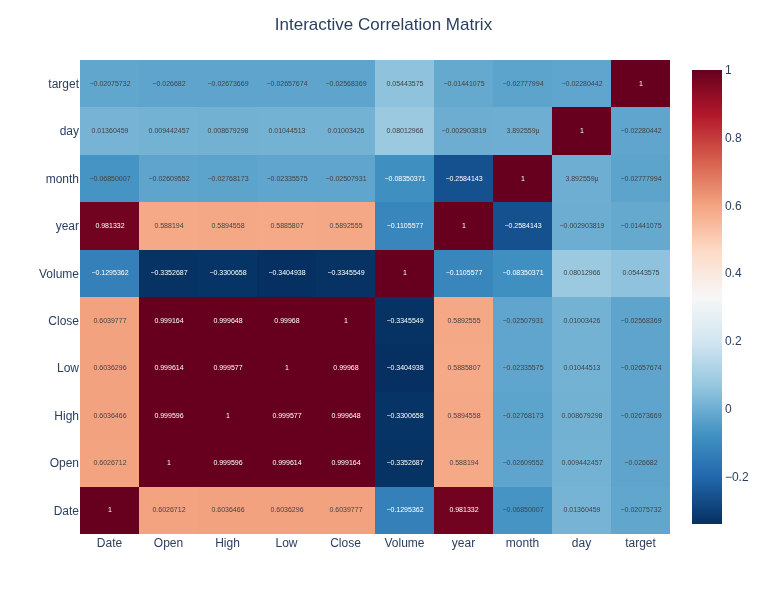

In [40]:
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    origin='lower',
    aspect='auto'
)
fig.update_layout(
    title="Interactive Correlation Matrix",
    title_x=0.5,
    width=800,
    height=600
)
fig.show()

## Univariate Analysis

In [41]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'year', 'month',
       'day', 'target'],
      dtype='object')

### Open

Text(0.5, 1.0, 'Histogram of Open')

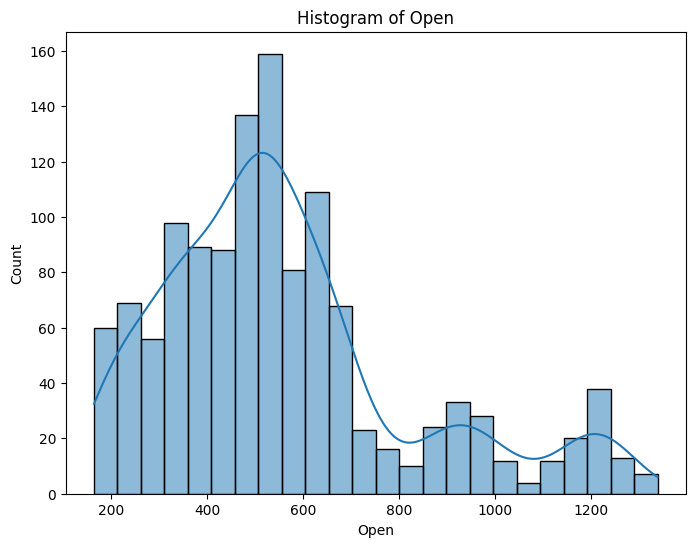

In [42]:
plt.figure(figsize=(8,6))
sns.histplot(df['Open'],kde=True)
plt.title("Histogram of Open")

Text(0.5, 1.0, 'Boxplot of Open')

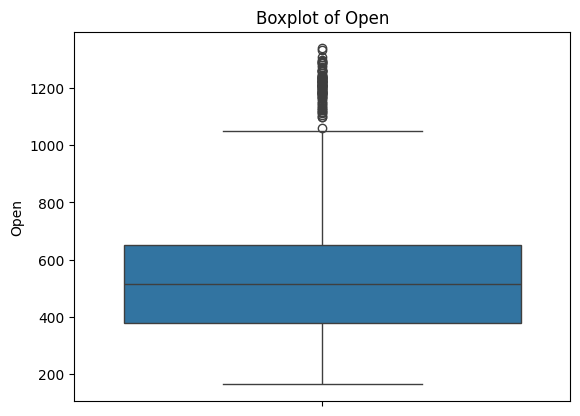

In [43]:

sns.boxplot(df['Open'])
plt.title("Boxplot of Open")

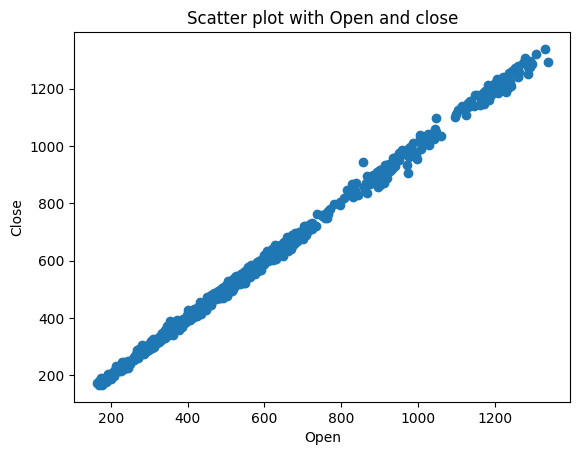

In [44]:
plt.scatter(x=df['Open'],y=df['Close'])
plt.xlabel('Open')
plt.ylabel("Close")
plt.title("Scatter plot with Open and close")
plt.show()

In [45]:
df['Open'].min()

np.float64(163.9600067138672)

In [46]:
df['Open'].max()

np.float64(1338.22998046875)

Text(0.5, 1.0, 'Histogram of High')

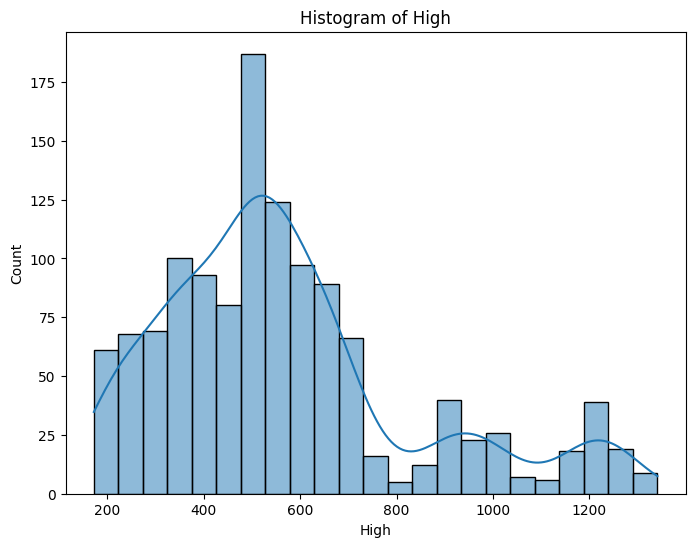

In [47]:
plt.figure(figsize=(8,6))
sns.histplot(df['High'],kde=True)
plt.title("Histogram of High")

Text(0.5, 1.0, 'Boxplot of High')

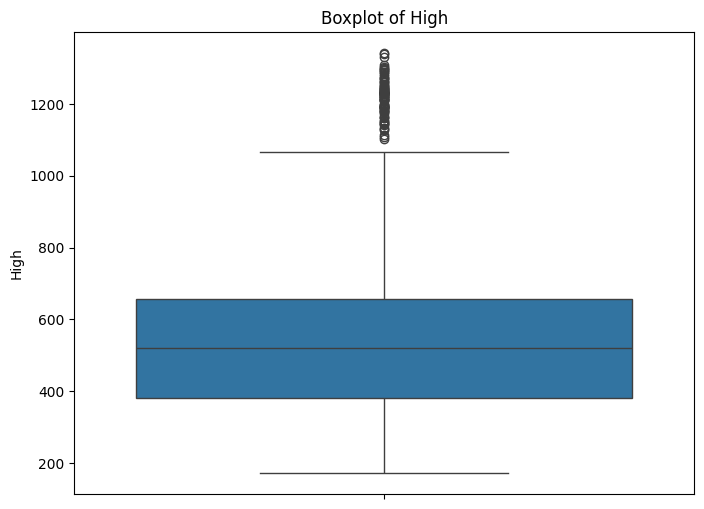

In [48]:
plt.figure(figsize=(8,6))
sns.boxplot(df['High'])
plt.title("Boxplot of High")

Text(0.5, 1.0, 'Histogram of Low')

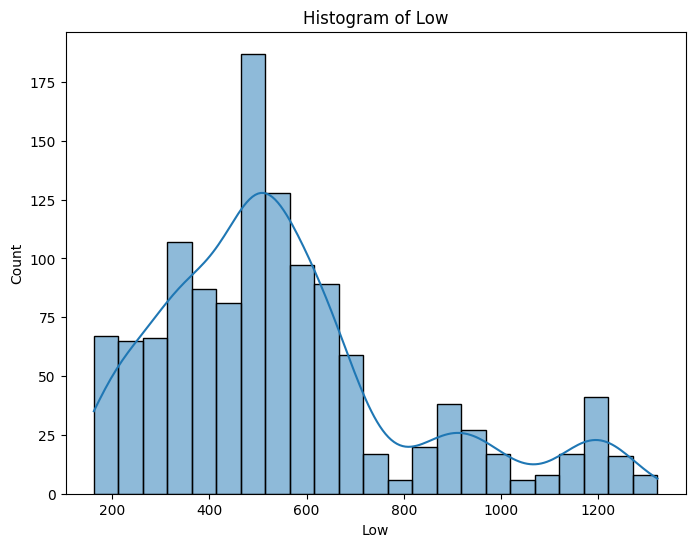

In [49]:
plt.figure(figsize=(8,6))
sns.histplot(df['Low'],kde=True)
plt.title("Histogram of Low")

Text(0.5, 1.0, 'Boxplot of Low')

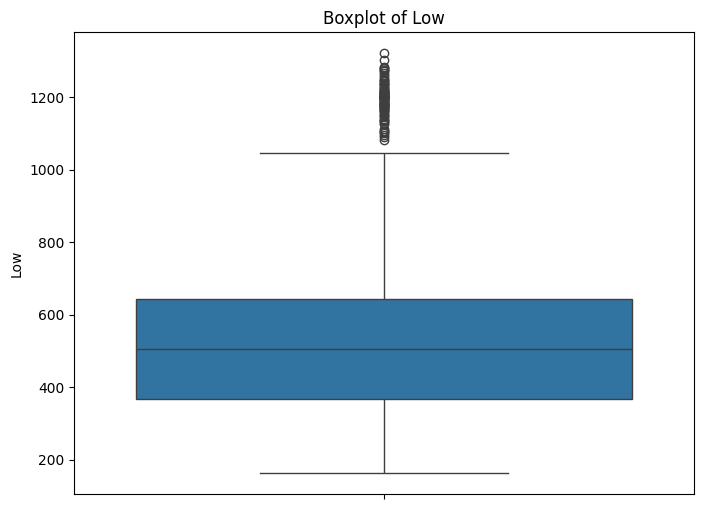

In [50]:
plt.figure(figsize=(8,6))
sns.boxplot(df['Low'])
plt.title("Boxplot of Low")

Text(0.5, 1.0, 'Histogram of Close')

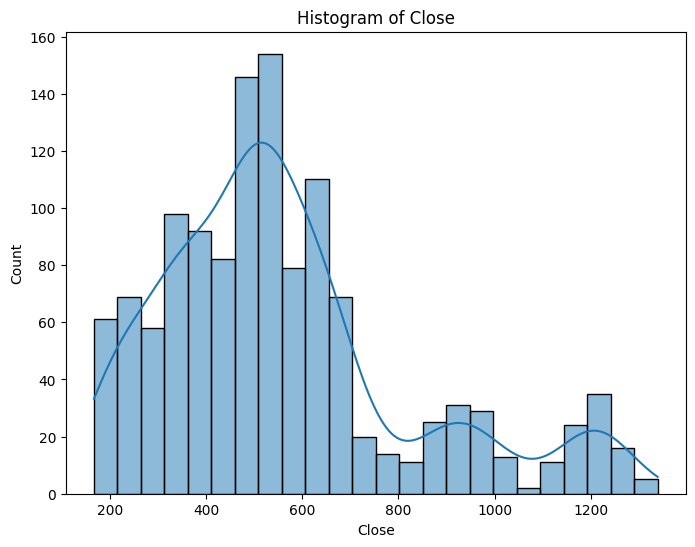

In [51]:
plt.figure(figsize=(8,6))
sns.histplot(df['Close'],kde=True)
plt.title("Histogram of Close")

Text(0.5, 1.0, 'Boxplot of Close')

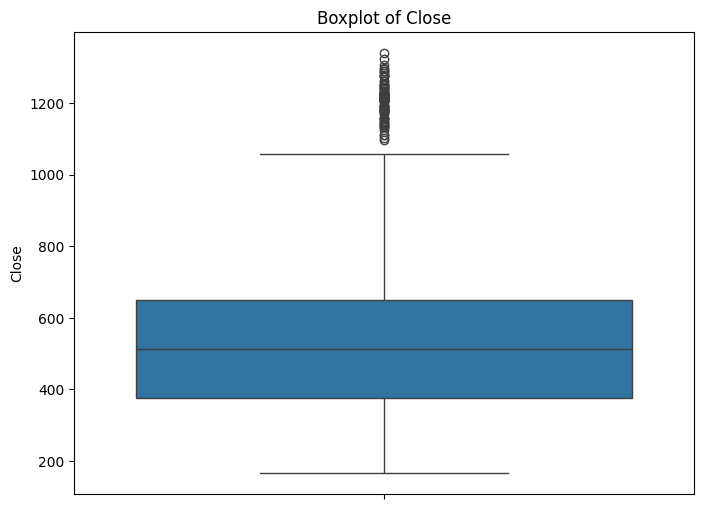

In [52]:
plt.figure(figsize=(8,6))
sns.boxplot(df['Close'])
plt.title("Boxplot of Close")

Text(0.5, 1.0, 'Histogram of Volume')

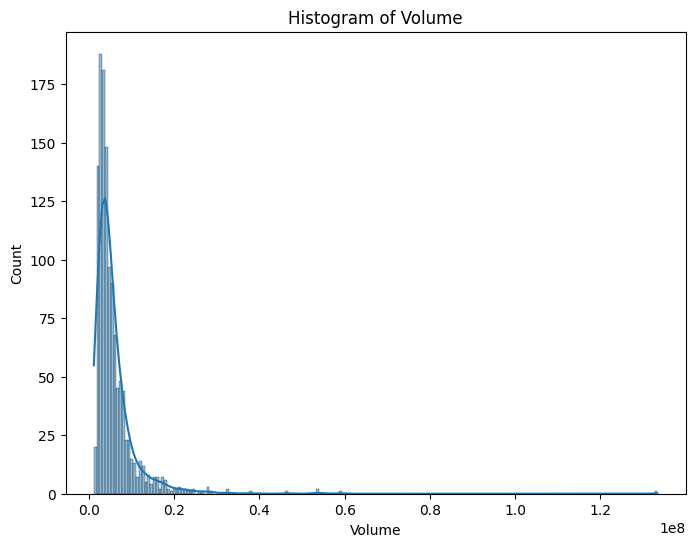

In [53]:
plt.figure(figsize=(8,6))
sns.histplot(df['Volume'],kde=True)
plt.title("Histogram of Volume")

Text(0.5, 1.0, 'Boxplot of Volume')

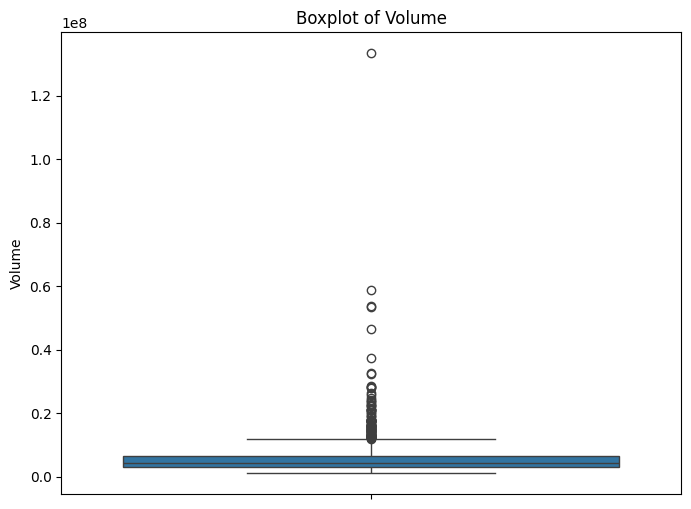

In [54]:
plt.figure(figsize=(8,6))
sns.boxplot(df['Volume'])
plt.title("Boxplot of Volume")

### From the boxplots we can we see that there are outliers we needed to handle them

In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1254.0,5.597642e+02,2.627333e+02,1.639600e+02,3.772025e+02,5.141000e+02,6.501800e+02,1.338230e+03
High,1254.0,5.674867e+02,2.653026e+02,1.720600e+02,3.826000e+02,5.199250e+02,6.569025e+02,1.341150e+03
Low,1254.0,5.520823e+02,2.602023e+02,1.627100e+02,3.679450e+02,5.060150e+02,6.430900e+02,1.321210e+03
Close,1254.0,5.599690e+02,2.631082e+02,1.663700e+02,3.758725e+02,5.138550e+02,6.497950e+02,1.339130e+03
Volume,1254.0,5.834022e+06,6.187126e+06,1.144000e+06,3.010200e+06,4.232650e+06,6.592775e+06,1.333875e+08
year,1254.0,2.022669e+03,1.489431e+00,2.020000e+03,2.021000e+03,2.023000e+03,2.024000e+03,2.025000e+03
month,1254.0,6.553429e+00,3.432384e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01
day,1254.0,1.572169e+01,8.764721e+00,1.000000e+00,8.000000e+00,1.600000e+01,2.300000e+01,3.100000e+01
target,1254.0,4.808612e-01,4.998329e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


In [56]:
df.select_dtypes(include='number').skew()

Open      1.014046
High      1.017021
Low       1.010136
Close     1.017777
Volume    9.316235
year     -0.021250
month    -0.015252
day       0.017550
target    0.076703
dtype: float64

In [57]:
df['Open'].max()

np.float64(1338.22998046875)

### Only going to handle the extreme value of volume and going to use the returns instead of raw prices

In [58]:
df['Volume'].min()

np.int64(1144000)

In [59]:
df['Volume'].max()

np.int64(133387500)

In [60]:
volume_threshold = df['Volume'].quantile(0.95)
volume_threshold

np.float64(14617604.999999998)

In [61]:
df['Volume'] = np.where(df['Volume']>volume_threshold,volume_threshold,df['Volume'])

In [62]:
df['Volume'].max()

np.float64(14617604.999999998)

Text(0.5, 1.0, 'Histogram of Volume')

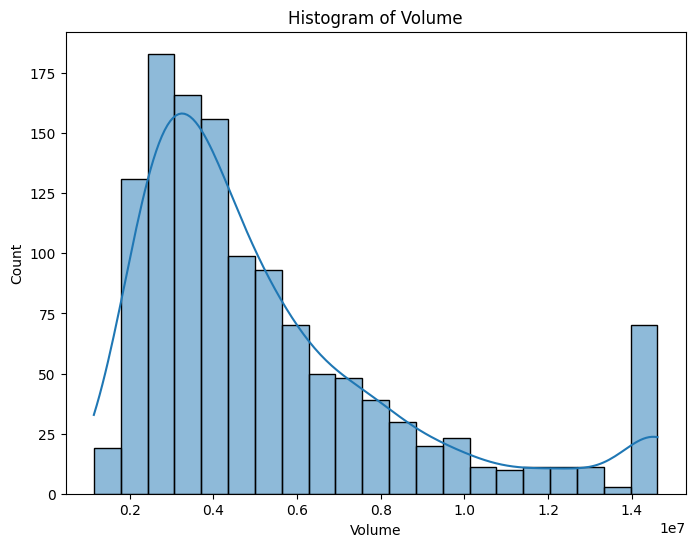

In [63]:
plt.figure(figsize=(8,6))
sns.histplot(df['Volume'],kde=True)
plt.title("Histogram of Volume")

#### Why returns instead of raw prices?

Raw stock prices drift (non-stationary).

Returns = percentage change between days.

Models work better because returns are more stable and capture actual growth/decline.

In [64]:
df.head()

,Date,Open,High,Low,Close,Volume,year,month,day,target
0,2020-09-04 09:30:00+05:30,520.179993,527.359985,485.980011,516.049988,8270100.0,2020,9,4,1
1,2020-09-08 09:30:00+05:30,498.399994,522.000000,495.000000,507.019989,5572700.0,2020,9,8,1
2,2020-09-09 09:30:00+05:30,519.210022,520.000000,492.570007,500.190002,6848100.0,2020,9,9,1
3,2020-09-10 09:30:00+05:30,503.350006,506.290009,478.839996,480.670013,6240200.0,2020,9,10,0
4,2020-09-11 09:30:00+05:30,486.489990,493.730011,476.809998,482.029999,5035200.0,2020,9,11,1


In [65]:
df['Close_Return'] = df['Close'].pct_change()
df['Close_return_per']= df['Close_Return']*100

In [66]:
df[['Close_Return','Close']].sample(10)

,Close_Return,Close
147,0.013876,554.580017
727,0.030520,425.779999
1131,-0.027415,866.679993
820,0.003894,453.760010
609,0.004067,362.950012
425,0.076473,187.639999
763,0.004564,396.200012
816,-0.025422,453.899994
1251,-0.018840,1208.250000
165,-0.011648,503.179993


In [67]:
df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))

<Axes: xlabel='LogReturn', ylabel='Close'>

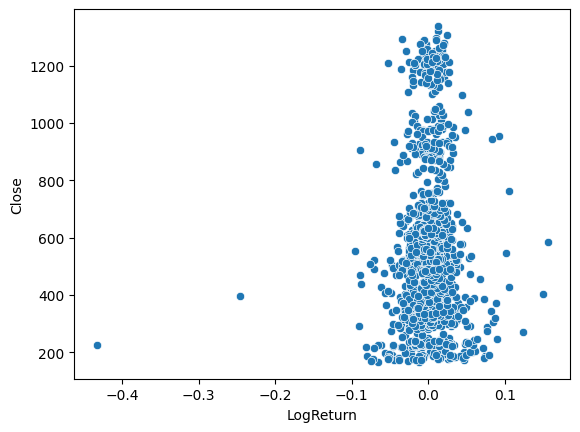

In [68]:
sns.scatterplot(x=df['LogReturn'],y=df['Close'])

### From the scatterplot we can see that most of the close values either up by 10% or down by 10%

In [69]:
df['Open_Return']  = df['Open'].pct_change()
df['High_Return']  = df['High'].pct_change()
df['Low_Return']   = df['Low'].pct_change()
df['Volume_Return'] = df['Volume'].pct_change()

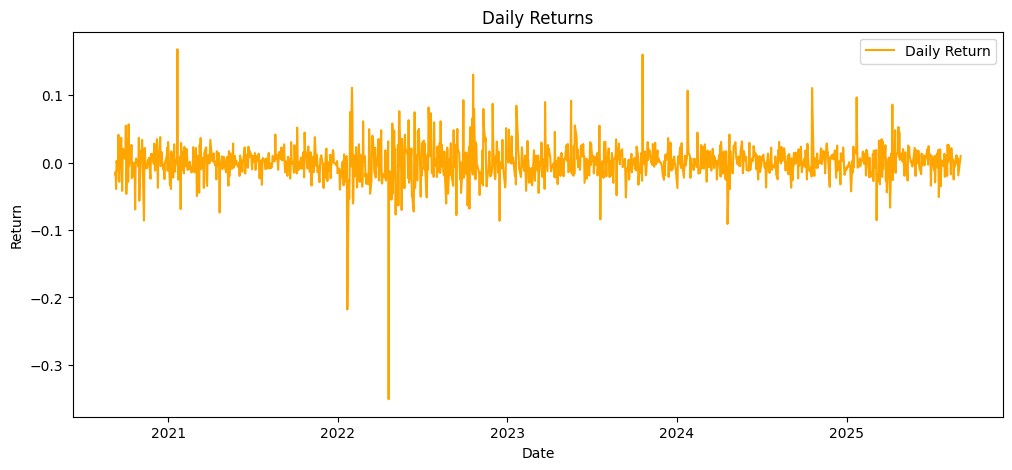

In [70]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close_Return'], label='Daily Return', color='orange')
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()


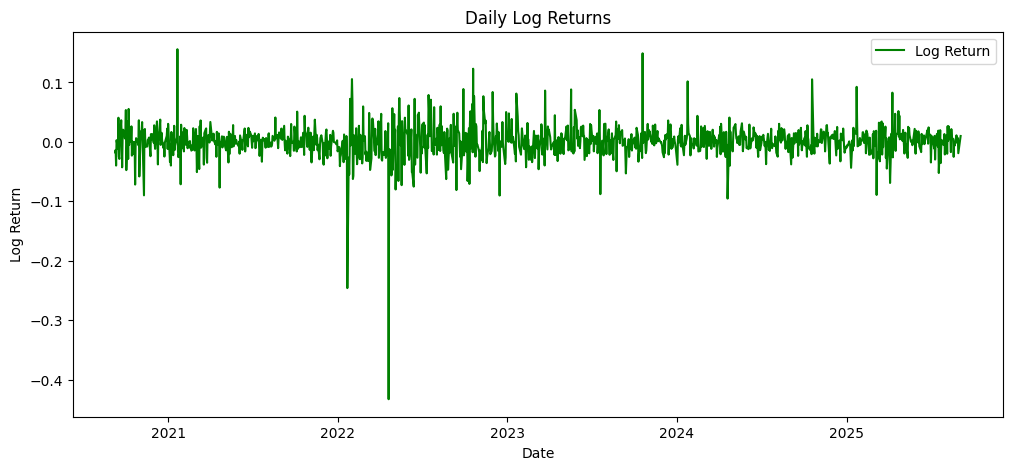

In [71]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['LogReturn'], label='Log Return', color='green')
plt.title("Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()


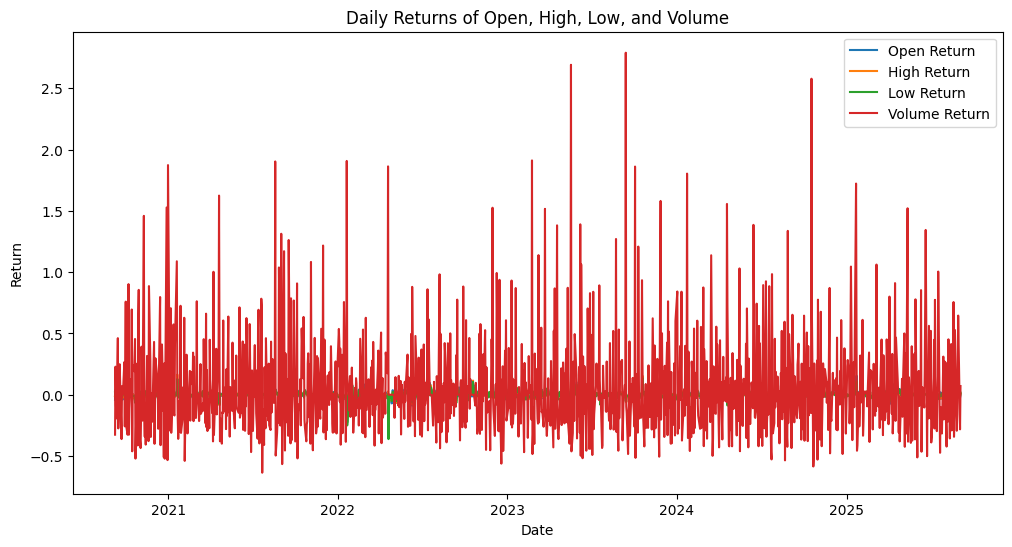

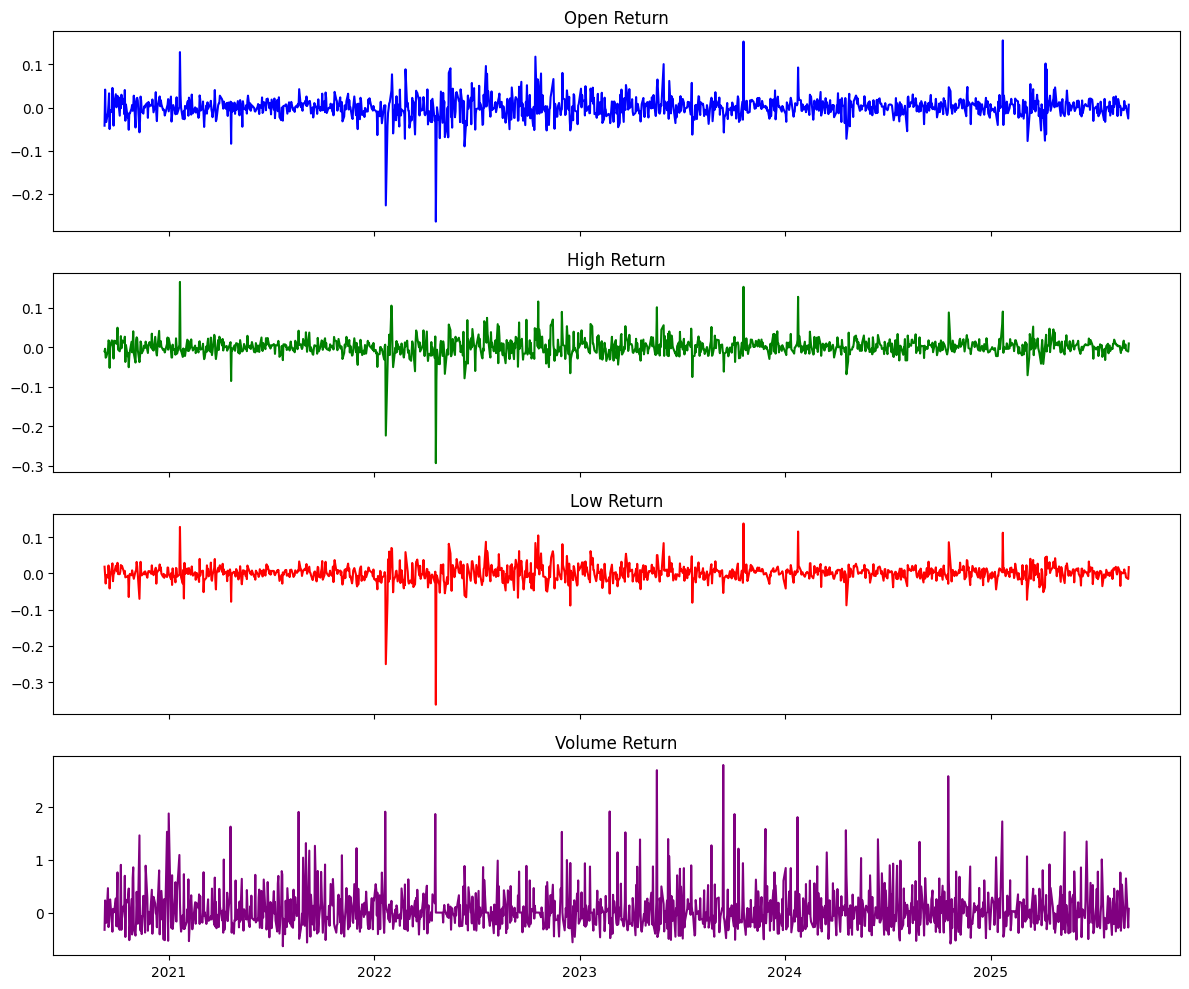

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Open_Return'], label='Open Return')
plt.plot(df['Date'], df['High_Return'], label='High Return')
plt.plot(df['Date'], df['Low_Return'], label='Low Return')
plt.plot(df['Date'], df['Volume_Return'], label='Volume Return')

plt.title("Daily Returns of Open, High, Low, and Volume")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()
fig, axes = plt.subplots(4, 1, figsize=(12,10), sharex=True)

axes[0].plot(df['Date'], df['Open_Return'], color='blue')
axes[0].set_title("Open Return")

axes[1].plot(df['Date'], df['High_Return'], color='green')
axes[1].set_title("High Return")

axes[2].plot(df['Date'], df['Low_Return'], color='red')
axes[2].set_title("Low Return")

axes[3].plot(df['Date'], df['Volume_Return'], color='purple')
axes[3].set_title("Volume Return")

plt.tight_layout()
plt.show()


Open, High, Low returns : all fluctuate around 0 (expected for daily % returns).

Notice clusters of spikes (big ups and downs grouped in time) : this is volatility clustering, a classic stock market property.

Volume_Return is much more erratic than price returns , sometimes surging +200% in a day  volume is less stable, but can signal market interest (spikes often occur around major events).

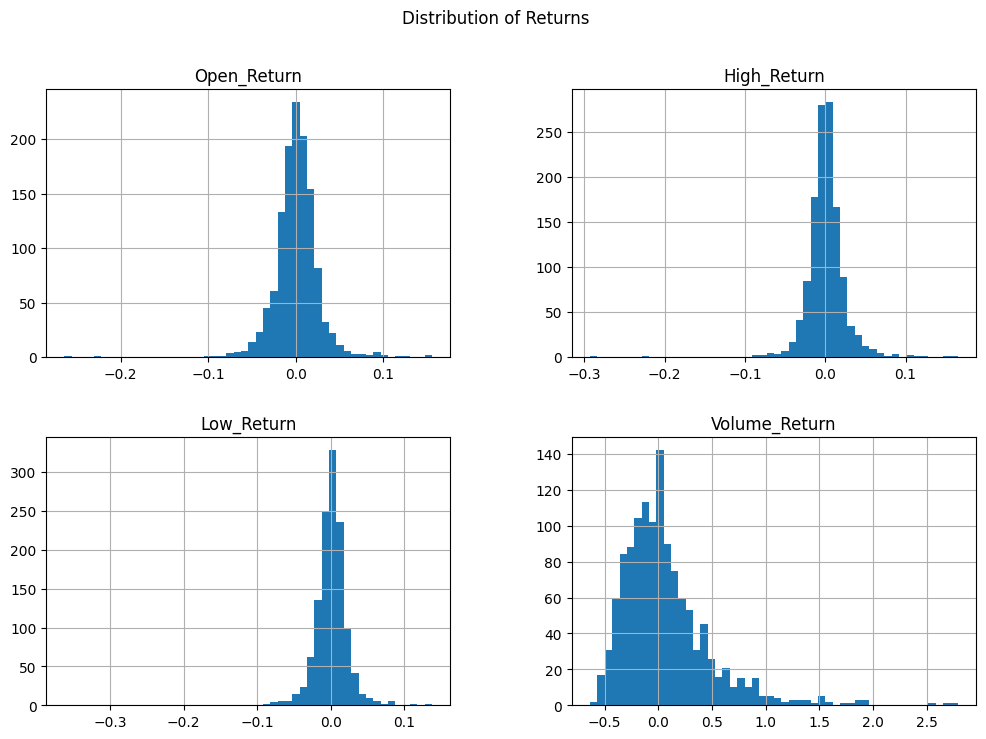

In [73]:
df[['Open_Return','High_Return','Low_Return','Volume_Return']].hist(
    bins=50, figsize=(12,8))
plt.suptitle("Distribution of Returns")
plt.show()


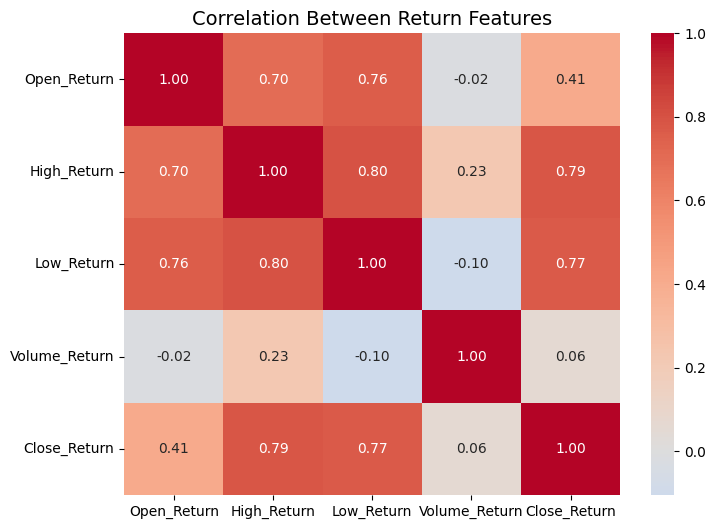

In [74]:
return_cols = ['Open_Return', 'High_Return', 'Low_Return', 'Volume_Return', 'Close_Return']

# Correlation matrix
corr = df[return_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Between Return Features", fontsize=14)
plt.show()

Strong correlations among price returns:

High_Return ↔ Low_Return (0.80)

High_Return ↔ Close_Return (0.79)

Low_Return ↔ Close_Return (0.77)

This makes sense: the daily high, low, and close move together since they come from the same candlestick.

Open_Return is moderately correlated with others:

Open_Return ↔ High_Return (0.70)

Open_Return ↔ Close_Return (0.41)

Opening gaps often behave differently from intraday moves (explains the weaker correlation with Close_Return).

Volume_Return is almost uncorrelated with price returns:

Very low values (−0.10 to +0.23)

Suggests price direction doesn’t directly depend on daily changes in trading volume (though volume spikes may coincide with big price moves).

In [75]:
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag2'] = df['Close'].shift(2)
df.head()


,Date,Open,High,Low,Close,Volume,year,month,day,target,Close_Return,Close_return_per,LogReturn,Open_Return,High_Return,Low_Return,Volume_Return,Close_Lag1,Close_Lag2
0,2020-09-04 09:30:00+05:30,520.179993,527.359985,485.980011,516.049988,8270100.0,2020,9,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-09-08 09:30:00+05:30,498.399994,522.000000,495.000000,507.019989,5572700.0,2020,9,8,1,-0.017498,-1.749830,-0.017653,-0.041870,-0.010164,0.018560,-0.326163,516.049988,NaN
2,2020-09-09 09:30:00+05:30,519.210022,520.000000,492.570007,500.190002,6848100.0,2020,9,9,1,-0.013471,-1.347084,-0.013562,0.041754,-0.003831,-0.004909,0.228866,507.019989,516.049988
3,2020-09-10 09:30:00+05:30,503.350006,506.290009,478.839996,480.670013,6240200.0,2020,9,10,0,-0.039025,-3.902515,-0.039807,-0.030546,-0.026365,-0.027874,-0.088769,500.190002,507.019989
4,2020-09-11 09:30:00+05:30,486.489990,493.730011,476.809998,482.029999,5035200.0,2020,9,11,1,0.002829,0.282935,0.002825,-0.033496,-0.024808,-0.004239,-0.193103,480.670013,500.190002


In [76]:
df['Volatility_10d'] = df['Close_Return'].rolling(window=10).std().shift(1)

In [77]:
df['Volume_Mean20']= df['Volume'].rolling(20).mean().shift(1)
df['Volume_Ratio_20d']= df['Volume']/df['Volume_Mean20']

In [78]:
df['Volume_Ratio_20d'].isna().sum()

np.int64(20)

In [79]:
# --- RSI (14) simple implementation ---
def compute_RSI(series, length=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    # Use exponential weighted average for smoothing (common)
    avg_gain = gain.ewm(alpha=1/length, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/length, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI_14'] = compute_RSI(df['Close']).shift(1)

# --- MACD (12,26) and MACD signal (9) ---
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = (ema12 - ema26).shift(1)
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean().shift(1)

# --- Bollinger Band Width (uses past 20-day std + mean) ---
rolling_mean_20 = df['Close'].rolling(20).mean().shift(1)
rolling_std_20  = df['Close'].rolling(20).std().shift(1)
bb_upper = rolling_mean_20 + 2 * rolling_std_20
bb_lower = rolling_mean_20 - 2 * rolling_std_20
df['Bollinger_Band_Width'] = (bb_upper - bb_lower) / rolling_mean_20  # relative width

# --- DayOfWeek (0=Monday) ---

# --- Target examples (choose one) ---
# Next-day return (decimal)
df['Target_Return_next'] = df['Close'].shift(-1) / df['Close'] - 1
# Next-day direction (1 if next day's close > today's close)
df['Target_Dir_next'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# --- Drop helper column and NaNs created by shifts/rollings ---
df = df.drop(columns=['Volume_Mean20'])
df = df.dropna()

In [80]:
df.shape

(1233, 27)

In [81]:
dd = df.corr()

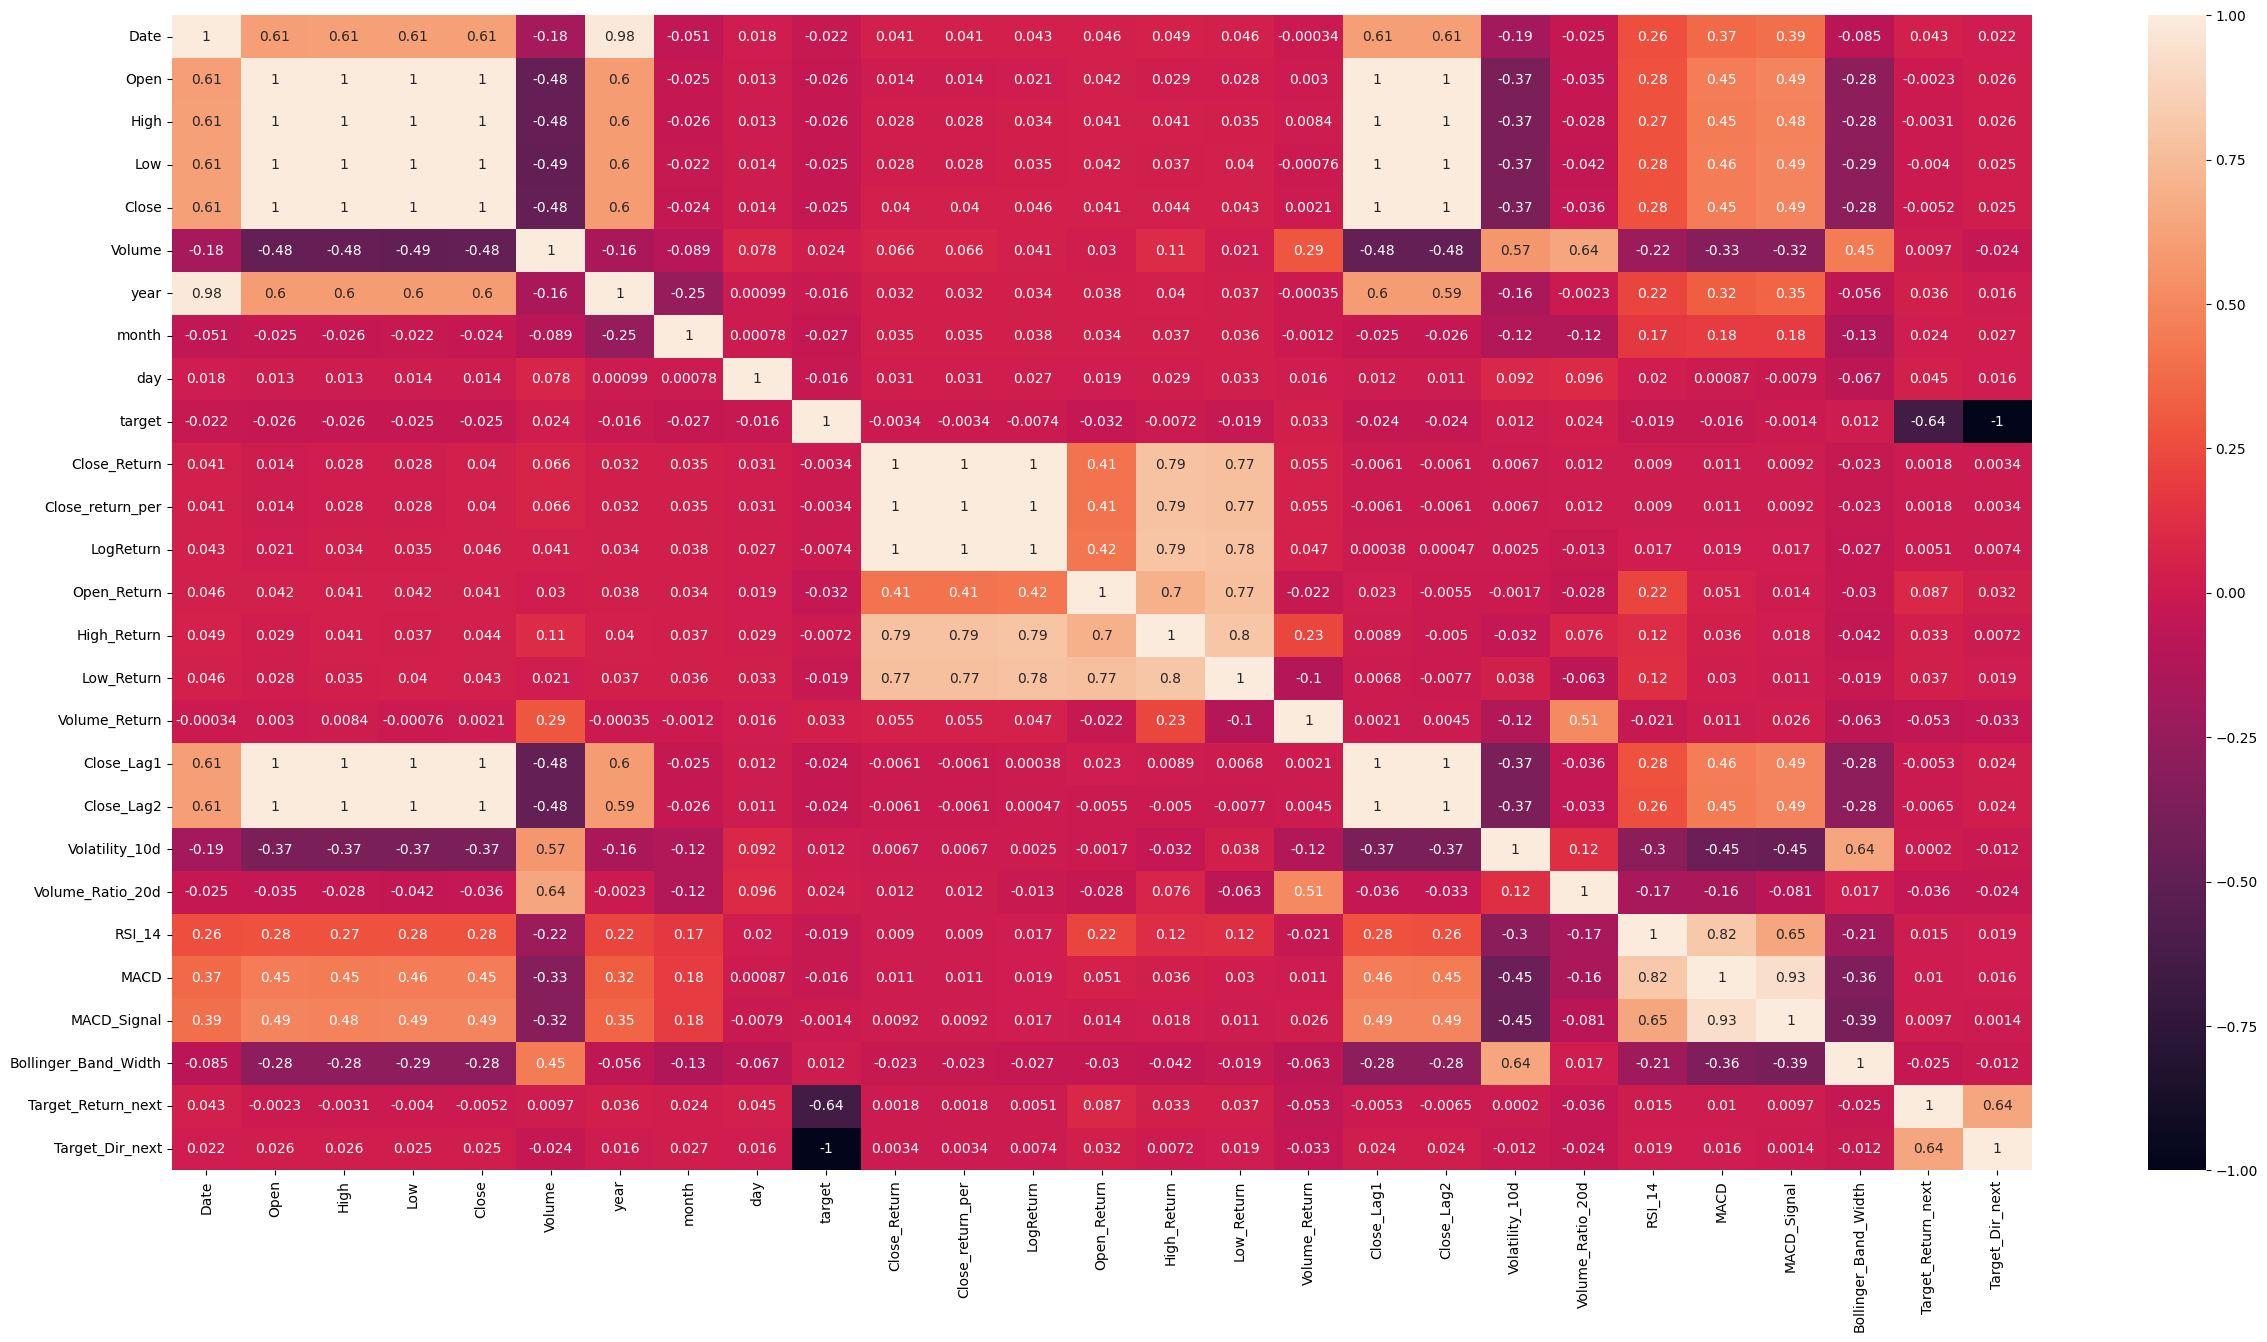

In [82]:
plt.figure(figsize=(30,15))
sns.heatmap(dd,annot=True)
plt.show()

### Further steps

Eda on new features 

check multicollinearity

feature selection



In [83]:
new_features = ['Close_Lag1','Close_Lag2','Volatility_10d','Volume_Ratio_20d','RSI_14','MACD','MACD_Signal','Bollinger_Band_Width','Target_Return_next','Target_Dir_next']
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Close_Lag1,1233.0,559.985271,263.852044,166.369995,373.470001,515.409973,651.450012,1339.130005
Close_Lag2,1233.0,559.433171,263.205894,166.369995,373.470001,515.409973,650.609985,1339.130005
Volatility_10d,1233.0,0.023440,0.014533,0.006014,0.014088,0.018473,0.030251,0.115726
Volume_Ratio_20d,1233.0,1.024422,0.527499,0.317018,0.702512,0.881333,1.162782,4.889583
RSI_14,1233.0,53.643301,13.247995,9.152344,44.455227,54.084199,63.921634,85.143919
MACD,1233.0,4.056320,16.362693,-59.233806,-4.753529,5.246136,12.879148,54.652794
MACD_Signal,1233.0,4.026125,15.494205,-48.342280,-4.447072,4.914641,12.263050,47.964788
Bollinger_Band_Width,1233.0,0.174328,0.132220,0.027751,0.101817,0.143323,0.205381,1.144416
Target_Return_next,1233.0,0.001089,0.027515,-0.351166,-0.011176,0.001033,0.013341,0.168543
Target_Dir_next,1233.0,0.518248,0.499870,0.000000,0.000000,1.000000,1.000000,1.000000


In [84]:
df[new_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 20 to 1252
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Close_Lag1            1233 non-null   float64
 1   Close_Lag2            1233 non-null   float64
 2   Volatility_10d        1233 non-null   float64
 3   Volume_Ratio_20d      1233 non-null   float64
 4   RSI_14                1233 non-null   float64
 5   MACD                  1233 non-null   float64
 6   MACD_Signal           1233 non-null   float64
 7   Bollinger_Band_Width  1233 non-null   float64
 8   Target_Return_next    1233 non-null   float64
 9   Target_Dir_next       1233 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 106.0 KB


In [85]:
df[new_features].duplicated().sum()

np.int64(0)

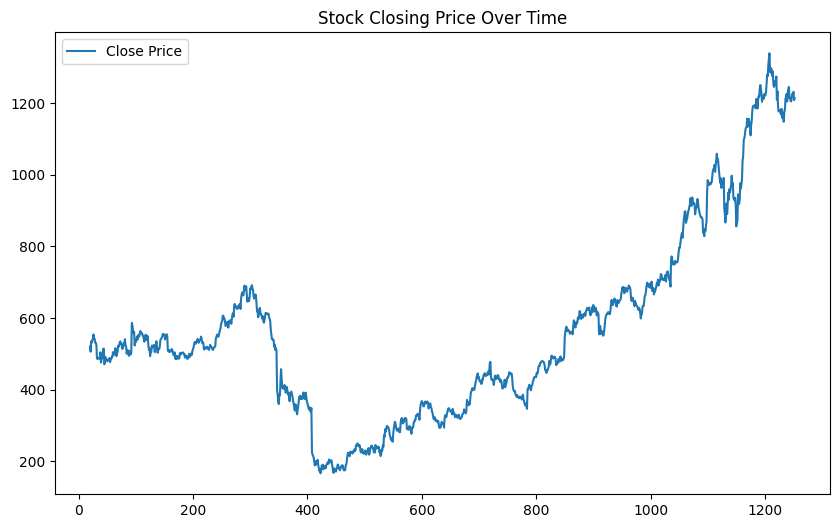

In [86]:
plt.figure(figsize=(10,6))
plt.plot(df['Close'],label='Close Price')
plt.title("Stock Closing Price Over Time")
plt.legend()
plt.show()

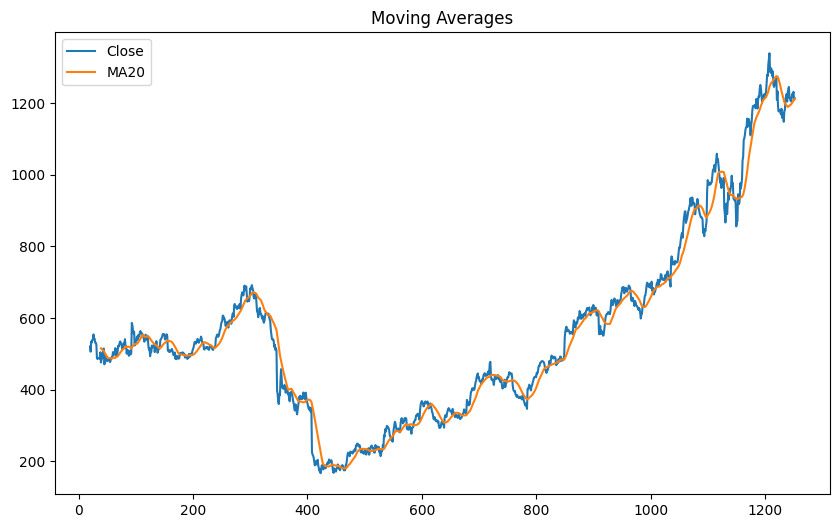

In [87]:
#Rolling Averages
plt.figure(figsize=(10,6))
plt.plot(df['Close'],label='Close')
plt.plot(df['Close'].rolling(20).mean(),label='MA20')
plt.title("Moving Averages")
plt.legend()
plt.show()

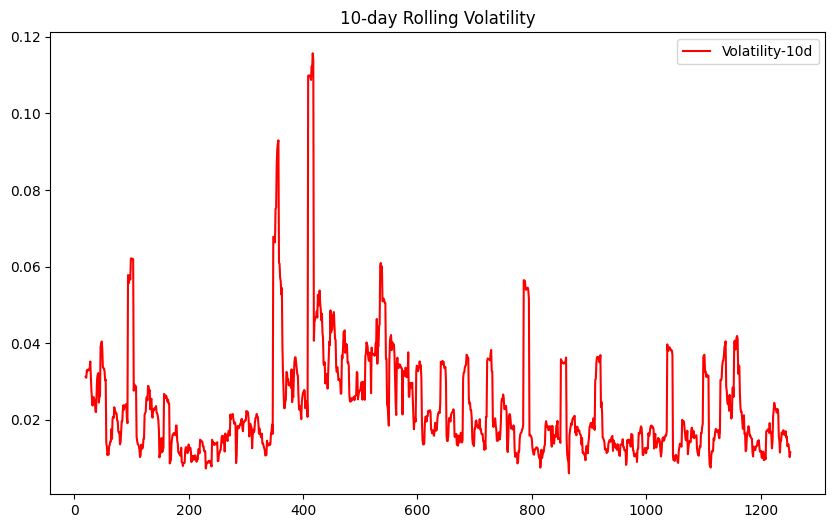

In [88]:
plt.figure(figsize=(10,6))
plt.plot(df['Volatility_10d'],color='red',label='Volatility-10d')
plt.title('10-day Rolling Volatility')
plt.legend()
plt.show()

In [89]:
df=df.set_index("Date")


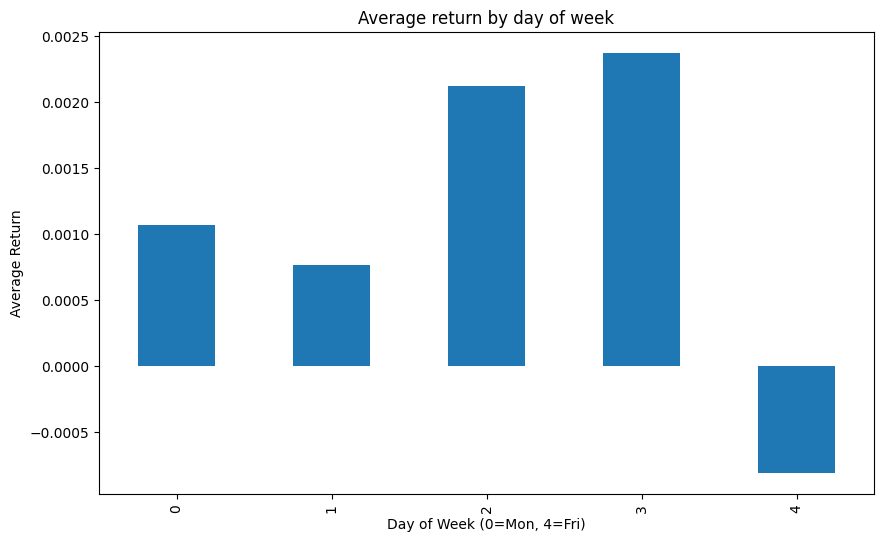

In [90]:
# -----------------------
# 8. Seasonality & Calendar Effects
# -----------------------
# Average return by day of week
df['DayOfWeek']=df.index.dayofweek

avg_returns = df.groupby('DayOfWeek')['Close_Return'].mean()
plt.figure(figsize=(10,6))
avg_returns.plot(kind='bar')
plt.xlabel("Day of Week (0=Mon, 4=Fri)")
plt.ylabel("Average Return")
plt.title('Average return by day of week')
plt.show()


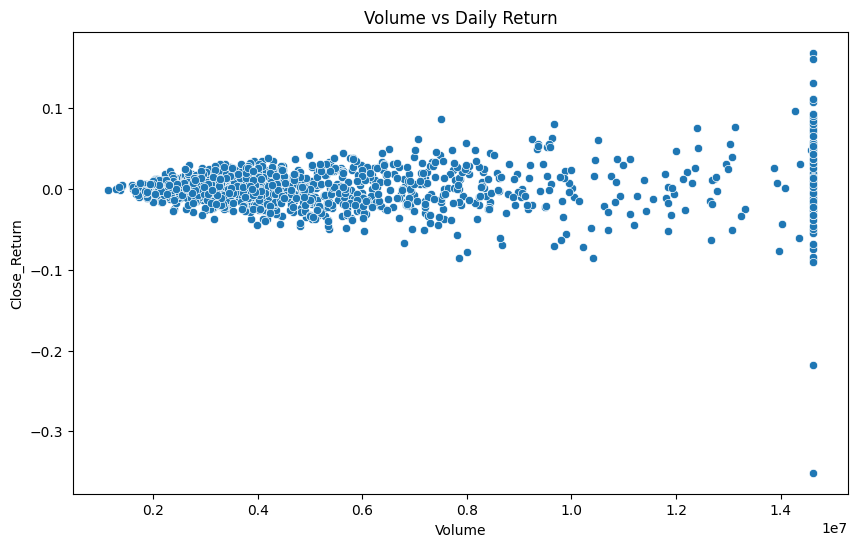

In [91]:
#Volume vs Price


plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Volume'],y=df['Close_Return'])
plt.title("Volume vs Daily Return")
plt.show()

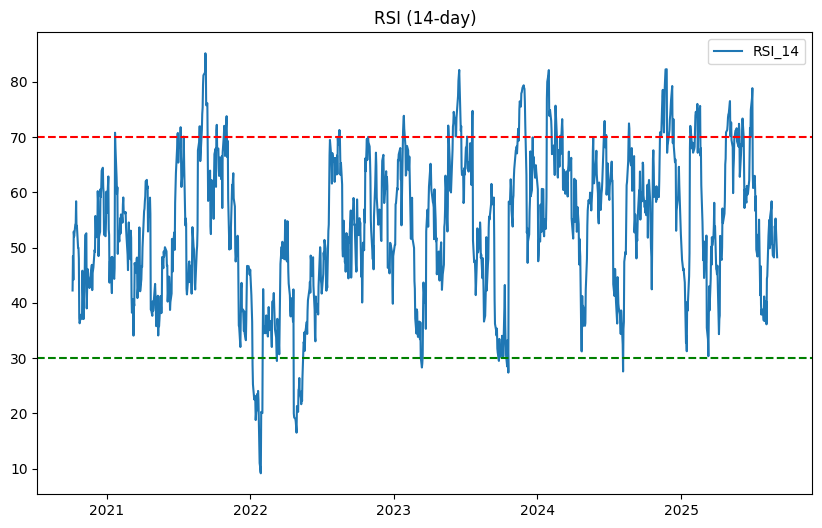

In [92]:
# RSI
plt.figure(figsize=(10,6))
plt.plot(df['RSI_14'], label="RSI_14")
plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")
plt.title("RSI (14-day)")
plt.legend()
plt.show()


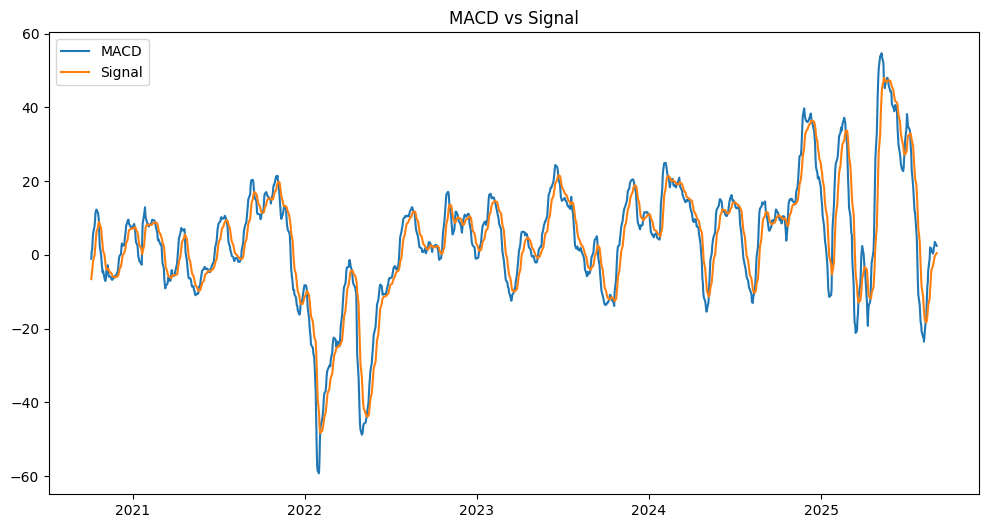

In [93]:
# MACD
plt.figure(figsize=(12,6))
plt.plot(df['MACD'], label="MACD")
plt.plot(df['MACD_Signal'], label="Signal")
plt.title("MACD vs Signal")
plt.legend()
plt.show()


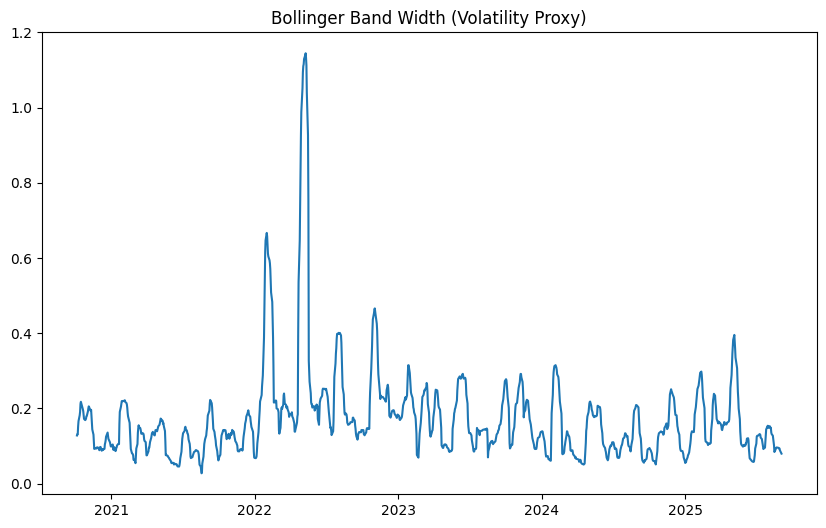

ADF Statistic: 0.7743376512219137
p-value: 0.9912104310302201
❌ The series is non-stationary, consider differencing/log transformation.


In [94]:

# Bollinger Band Width
plt.figure(figsize=(10,6))
plt.plot(df['Bollinger_Band_Width'])
plt.title("Bollinger Band Width (Volatility Proxy)")
plt.show()

# -----------------------
# 11. Stationarity Check
# -----------------------
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("✅ The series is stationary.")
else:
    print("❌ The series is non-stationary, consider differencing/log transformation.")

## A — Visual insights (what is theplots mean)

### Bollinger Band Width (Volatility proxy)

Spikes around 2022 mean short periods of very high volatility (likely news / earnings / market shock).

Most of the time the width is low—so regime changes (calm → volatile) happen rarely but matter.

### MACD vs Signal

MACD and Signal track closely (expected). Crossovers are frequent — good for short-term momentum signals.

Large negative dip in 2022 shows a strong downward momentum episode; recent large swings in 2025 too.

### RSI (14-day)

RSI oscillates mostly between 30–70 with many excursions. Frequent overbought/oversold cycles → momentum/reversion behavior exists.

But RSI rarely stays extreme for long — useful as a short-term contrarian or filter feature.

### Volume vs Daily Return scatter

No strong linear relationship — most returns cluster near 0 even across volumes.

Extreme returns sometimes coincide with very high volume (vertical strip at large volumes) — spikes matter, but volume alone is noisy.

### 10-day Rolling Volatility

Matches Bollinger spikes: volatility regimes are visible. Useful for feature like Volatility_10d > threshold (event flags).

### Overall behavioural insight

Market shows regime changes (calm vs spiky).

Many indicators move together (momentum indicators correlate), so multicollinearity is present.

Returns are small and noisy; predictive signal will be weak — expect modest accuracy improvements vs baseline.

In [95]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [96]:
x = df.drop(columns=['Close'])

x= add_constant(x)

ddd = pd.DataFrame()

ddd['Close']= x.columns
ddd['VIF'] = [variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
ddd

/home/alen_sunny/machine_learning/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning:

divide by zero encountered in scalar divide

/home/alen_sunny/machine_learning/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



,Close,VIF
0,const,0.000000
1,Open,4715.197248
2,High,3486.199160
3,Low,3942.543911
4,Volume,5.444901
5,year,1.903774
6,month,1.217182
7,day,1.077563
8,target,inf
9,Close_Return,inf


### From the Varience Inflation factor

VIF ≈ 1 : no multicollinearity.

VIF 1–5 : moderate but usually fine.

VIF > 10 : strong multicollinearity (problematic).

VIF = (inf) : perfect collinearity (one feature is a near-exact linear combo of another)

#### Extremely high VIFs (>> 10)

Open (4712), High (3516), Low (3964), Close_Lag1 (2837), Close_Lag2 (812), LogReturn (179), MACD (22), MACD_Signal (12)

These are heavily redundant. Example: Open, High, Low, and Close are strongly correlated (from same candlestick). Similarly, Close_Lag1 and Close_Lag2 overlap with Close/returns.

#### Moderate VIFs (2–10)

Open_Return (7.6), High_Return (7.6), Low_Return (9.7), RSI_14 (5.7), Volume_Ratio_20d (3.5), Volatility_10d (2.7)

These are acceptable, though Low_Return is close to problematic.

Since Open/High/Low/Close returns are highly correlated, you could pick just one (Close_Return) plus maybe the High-Low spread as a separate measure.

#### Low VIFs (<2)

Volume (5.4 is borderline but ok), Volume_Return (1.9), DayOfWeek (1.0), Target_Return_next (1.7)

These are safe and likely independent enough to keep.

#### Infinite VIF (inf)

target, Close_Return, Close_return_per, Target_Dir_next

This happens when the column is perfectly collinear with others (duplicate info).

Example: Close_Return and Close_return_per are the same thing scaled differently → drop one.

Target_Dir_next is derived from Target_Return_next (direction is just sign of return) → they are collinear, so keep only one depending on whether you want regression or classification.

In [97]:
data = df.copy()

In [98]:
redundant_features =['Open','High','Low','Close','Close_return_per','LogReturn','Close_Lag2','MACD_Signal']

In [99]:
data = data.drop(columns=redundant_features)

In [100]:
data_for_VIF = data.drop(columns=['Close_Return'])
new = pd.DataFrame()
data_for_VIF= add_constant(data_for_VIF)

new['Close_Return'] = data_for_VIF.columns
new['VIF']= [variance_inflation_factor(data_for_VIF.values,i)for i in range(data_for_VIF.shape[1])]
new

/home/alen_sunny/machine_learning/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning:

divide by zero encountered in scalar divide

/home/alen_sunny/machine_learning/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



,Close_Return,VIF
0,const,0.000000
1,Volume,4.902757
2,year,1.861561
3,month,1.187132
4,day,1.050704
5,target,inf
6,Open_Return,2.853464
7,High_Return,4.049730
8,Low_Return,4.520317
9,Volume_Return,1.876368


<Axes: >

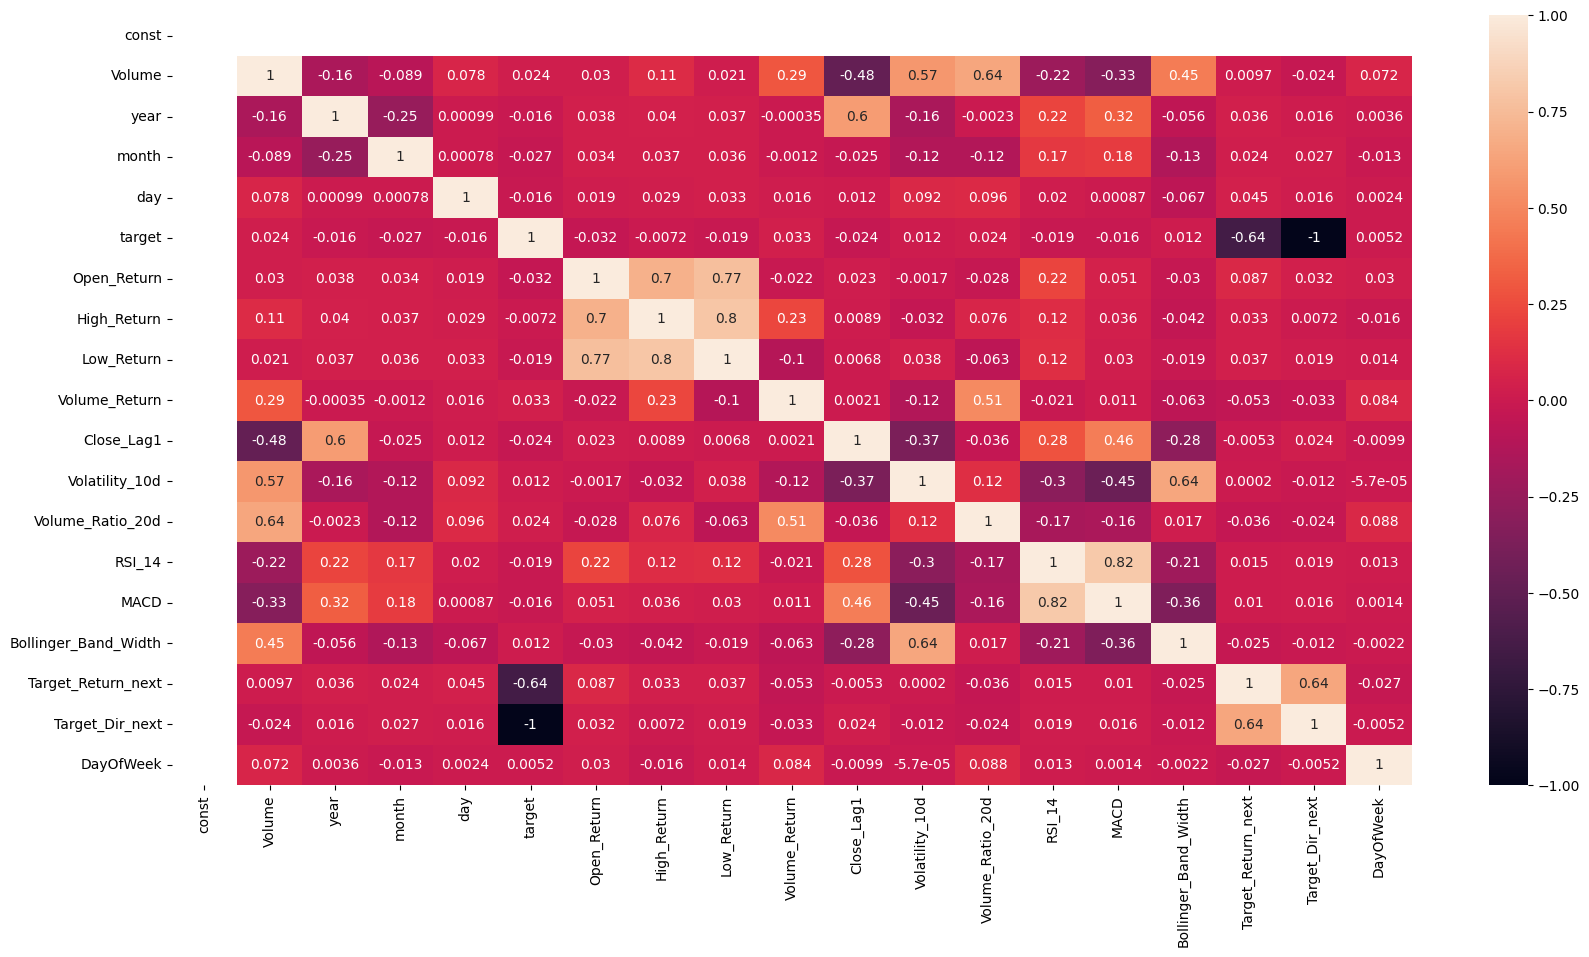

In [101]:
plt.figure(figsize=(20,10))
data_for_VIF_corr = data_for_VIF.corr()
sns.heatmap(data_for_VIF_corr,annot=True)

## Data Preprocessing

### For Regression Models

In [102]:
data =data.reset_index()

In [103]:
X = data.drop(columns=['Target_Return_next','Target_Dir_next',"Date",'target'])

In [104]:
X.head()

,Volume,year,month,day,Close_Return,Open_Return,High_Return,Low_Return,Volume_Return,Close_Lag1,Volatility_10d,Volume_Ratio_20d,RSI_14,MACD,Bollinger_Band_Width,DayOfWeek
0,4088100.0,2020,10,5,0.034966,-0.018647,-0.010221,-0.001989,-0.326641,503.059998,0.031177,0.753629,42.225641,-1.073194,0.128235,0
1,4199000.0,2020,10,6,-0.028388,0.023520,0.001593,0.004903,0.027128,520.650024,0.030967,0.805107,48.423000,0.989208,0.131664,1
2,7988700.0,2020,10,7,0.056912,-0.001388,0.028113,0.023128,0.902524,505.869995,0.032924,1.552177,44.138658,1.414743,0.131185,2
3,5386500.0,2020,10,8,-0.005368,0.029884,-0.002777,0.016149,-0.325735,534.659973,0.032638,1.035109,52.883571,4.028653,0.152950,3
4,4781300.0,2020,10,9,0.014385,0.008154,0.017346,0.020700,-0.112355,531.789978,0.033099,0.926408,52.009491,5.801733,0.166471,4


In [105]:
y= data['Target_Return_next']

In [106]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error

In [107]:
y.head()

0   -0.028388
1    0.056912
2   -0.005368
3    0.014385
4    0.000686
Name: Target_Return_next, dtype: float64

In [108]:
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
sc= StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train), columns=X.columns, index=x_train.index)
x_test = pd.DataFrame(sc.transform(x_test), columns=X.columns, index=x_test.index)

### Algorithm based feature selection Linear models

In [109]:
linear_model = LinearRegression()
rfe = RFE(linear_model,step=1,n_features_to_select=10)

In [110]:
rfe.fit(x_train,y_train)

,estimator,LinearRegression()
,n_features_to_select,10
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [111]:
selected_columns = X.columns[rfe.support_]

In [112]:
print('The result of RFE')
selected_columns

The result of RFE


Index(['Volume', 'year', 'Close_Return', 'Open_Return', 'High_Return',
       'Low_Return', 'Volume_Return', 'Volume_Ratio_20d',
       'Bollinger_Band_Width', 'DayOfWeek'],
      dtype='object')

In [113]:
lasso = LassoCV(max_iter=100000,random_state=42).fit(x_train,y_train,)
selected = X.columns[(lasso.coef_!=0)]
selected

Index([], dtype='object')

In [114]:
lasso.coef_

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0., -0.,  0., -0.,  0.,
        0., -0., -0.])

RFE R²: -9.210179107532745e-05


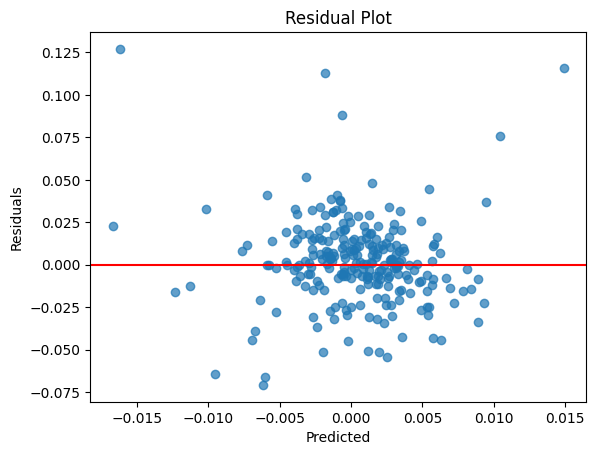

In [115]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Train model with selected features
model_rfe = LinearRegression().fit(x_train[selected_columns], y_train)
pred_rfe = model_rfe.predict(x_test[selected_columns])

# R² score
print("RFE R²:", r2_score(y_test, pred_rfe))

# Residuals = actual - predicted
residuals = y_test - pred_rfe

# Plot residuals
plt.scatter(pred_rfe, residuals, alpha=0.7)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Residuals are not centered around zero :systematic bias exists.

Almost all residuals are positive : the model consistently underestimates the target.

Residuals show an upward increasing trend with predictions : error grows as predictions increase.

The pattern is non-random and structured, meaning the model is missing important relationships.

Suggests the linearity assumption is violated : target vs features relationship is nonlinear.

Indicates high model bias (underfitting).

In [116]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'year', 'month', 'day',
       'target', 'Close_Return', 'Close_return_per', 'LogReturn',
       'Open_Return', 'High_Return', 'Low_Return', 'Volume_Return',
       'Close_Lag1', 'Close_Lag2', 'Volatility_10d', 'Volume_Ratio_20d',
       'RSI_14', 'MACD', 'MACD_Signal', 'Bollinger_Band_Width',
       'Target_Return_next', 'Target_Dir_next', 'DayOfWeek'],
      dtype='object')

In [117]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVR

svr = SVR(kernel="linear")   # needs a linear kernel for feature importance
selector = RFE(estimator=svr, n_features_to_select=10, step=1)
selector.fit(x_train, y_train)

selected_features = X.columns[selector.support_]
print("Selected features:", selected_features)


Selected features: Index(['Volume', 'year', 'month', 'Close_Return', 'Open_Return', 'Low_Return',
       'Volume_Return', 'RSI_14', 'MACD', 'DayOfWeek'],
      dtype='object')


# We now going to train the Linear models using the features
'Volume', 'year', 'month', 'Close_Return', 'Open_Return', 'Low_Return',
       'Volume_Return', 'RSI_14', 'MACD', 'DayOfWeek']

In [118]:
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.svm import SVC,SVR
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import math


### Raw Linear Models Linear

LinearRegression:RMSE=0.02575806202197685 ,R2=0.006207047904020713
**************************************************


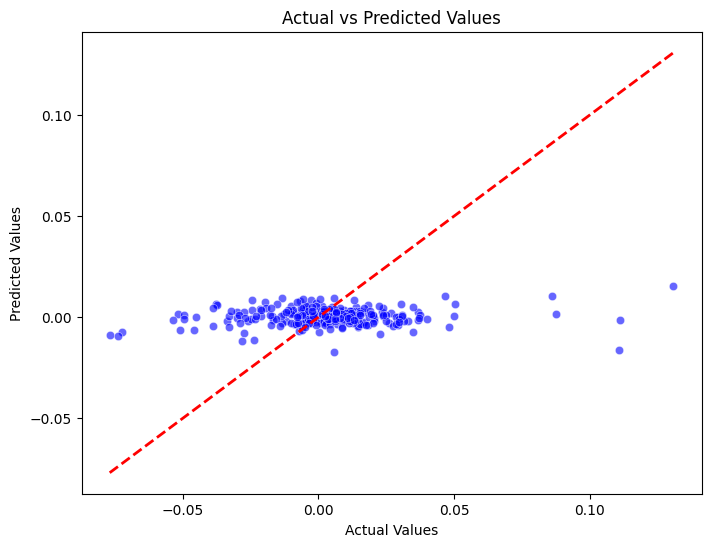

Lasso:RMSE=0.02589837971359107 ,R2=-0.0046498677021551416
**************************************************


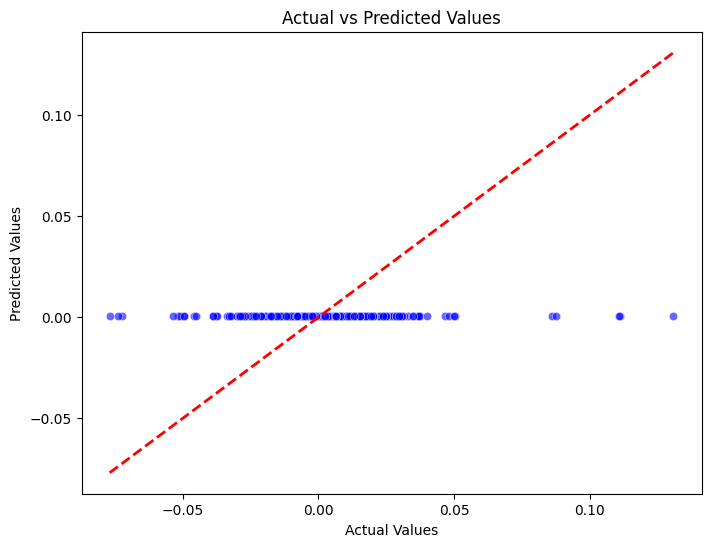

Ridge:RMSE=0.025756958243808473 ,R2=0.006292217623765084
**************************************************


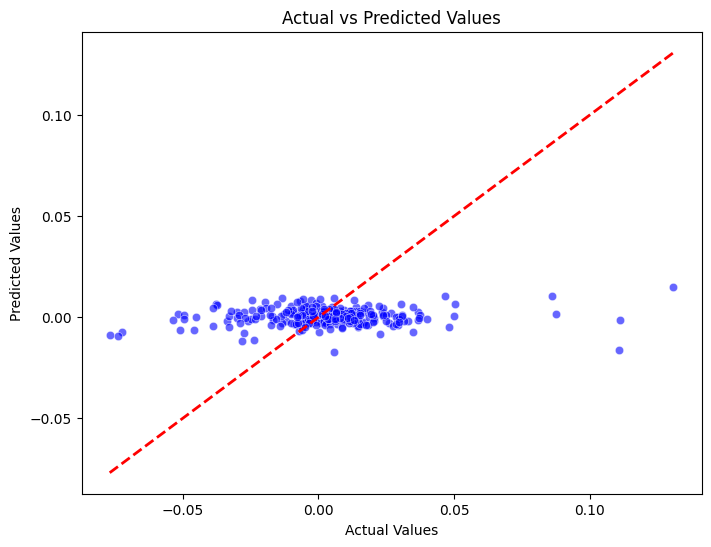

In [119]:
regression_linear_pipeline={
    'LinearRegression':Pipeline(steps=[('model',LinearRegression())]),
    'Lasso':Pipeline(steps=[('model',Lasso())]),
    'Ridge':Pipeline(steps=[('model',Ridge())])

}

for name,pipe in regression_linear_pipeline.items():
    pipe.fit(x_train,y_train)
    y_pred = pipe.predict(x_test)
    
    rmse = mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    print(f'{name}:RMSE={math.sqrt(rmse)} ,R2={r2}')
    print('*'*50)
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # perfect fit line
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.show()

### Hyper Parameter Tuning Linear

In [120]:
param_grid_linear={
    'model__fit_intercept':[True,False]   
}
param_grid_rigde_lasso={
    'model__alpha':[0.01,0.1,1.0,10.0,50.0,100.0],
    'model__max_iter':[100,1000,2000,5000,10000],
    'model__random_state':[22,42,55]
}

grids_linear_regression ={
    'LinearRegression': GridSearchCV(regression_linear_pipeline['LinearRegression'],param_grid_linear,cv=5,scoring='r2'),
    'Ridge':GridSearchCV(regression_linear_pipeline['Ridge'],param_grid_rigde_lasso,cv=5,scoring='r2'),
    'Lasso':GridSearchCV(regression_linear_pipeline['Lasso'],param_grid_rigde_lasso,cv=5,scoring='r2',error_score='raise')
}

for name,grid in grids_linear_regression.items():
    print(f"\n{name} Model")
    grid.fit(x_train, y_train)
    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    print("Test R2:", grid.score(x_test, y_test))
    print("="*60)


LinearRegression Model
Best Params: {'model__fit_intercept': False}
Best CV Score: -0.05316941913930244
Test R2: 0.0007757415993084882

Ridge Model
Best Params: {'model__alpha': 100.0, 'model__max_iter': 100, 'model__random_state': 22}
Best CV Score: -0.046729493447579616
Test R2: 0.008527401260626677

Lasso Model
Best Params: {'model__alpha': 0.01, 'model__max_iter': 100, 'model__random_state': 22}
Best CV Score: -0.02030508981854422
Test R2: -0.0046498677021551416


### Raw Tree Models 

In [121]:
x_train_tree,x_test_tree,y_train_tree,y_test_tree = train_test_split(X,y,test_size=0.2,random_state=42)

DecisionTreeRegressor:RMSE=0.025756958243808473 ,R2=-2.837576018914564
**************************************************


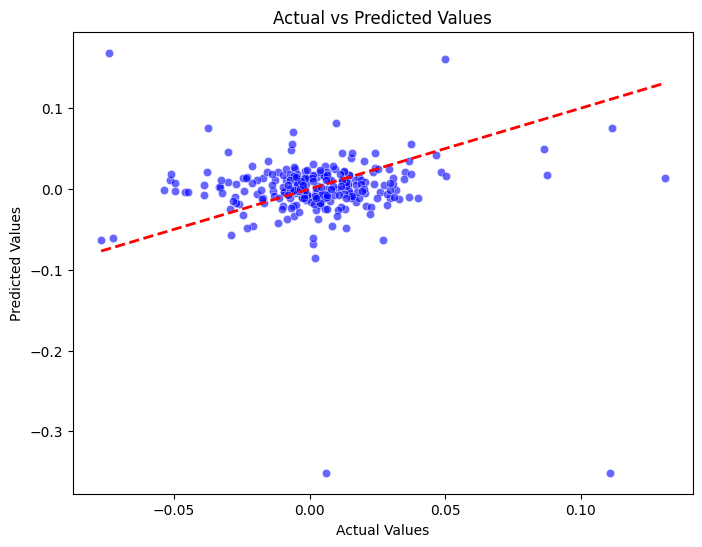

In [122]:
regression_tree_pipeline={
    'DecisionTreeRegressor':Pipeline(steps=[('model',DecisionTreeRegressor())])
}

for name,pipe in regression_tree_pipeline.items():
    pipe.fit(x_train_tree,y_train_tree)
    y_pred_tree = pipe.predict(x_test_tree)
    
    rmse = mean_squared_error(y_test_tree,y_pred)
    r2 = r2_score(y_test,y_pred_tree)
    print(f'{name}:RMSE={math.sqrt(rmse)} ,R2={r2}')
    print('*'*50)
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_test_tree, y=y_pred_tree, color='blue', alpha=0.6)
    plt.plot([y_test.min(), y_test_tree.max()], [y_test_tree.min(), y_test_tree.max()], 'r--', linewidth=2)  # perfect fit line
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.show()

### Hyperparameter Tree

In [123]:
param_grid_tree = {
    'model__max_depth': [1, 3, 5, 10],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}
grids_tree_regression={
    'DecisionTreeRegressor': GridSearchCV(regression_tree_pipeline['DecisionTreeRegressor'],param_grid_tree,cv=5,scoring='r2'),

}
for name,grid in grids_tree_regression.items():
    print(f"\n{name} Model")
    grid.fit(x_train_tree, y_train_tree)
    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    print("Test R2:", grid.score(x_test_tree, y_test_tree))
    print("="*60)
    


DecisionTreeRegressor Model
Best Params: {'model__criterion': 'absolute_error', 'model__max_depth': 1, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best CV Score: -0.02199279908117575
Test R2: -0.06650347707442772


### SVR and KNRegressior


KNN Model
Best Params: {'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
Best CV Score: -0.1324805639197523
Test RMSE: 0.02651762568288766
Test R2: -0.05326781876456854


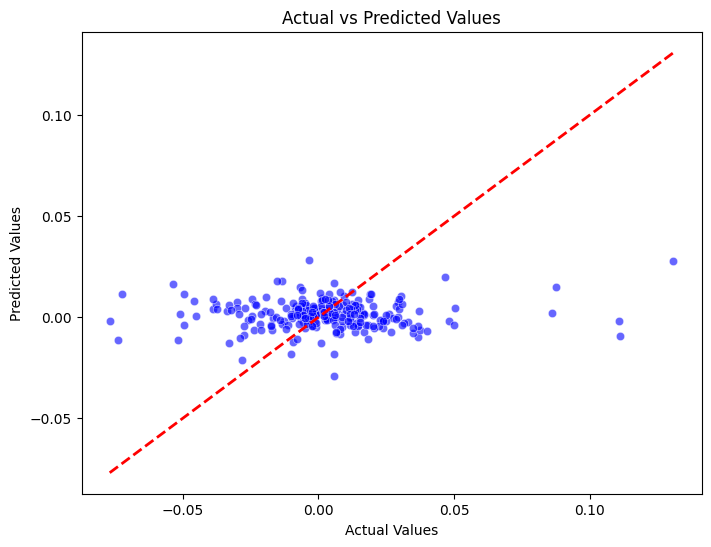


SVM Model
Best Params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Score: -0.3408703317160477
Test RMSE: 0.027440095013933522
Test R2: -0.1278225270528761


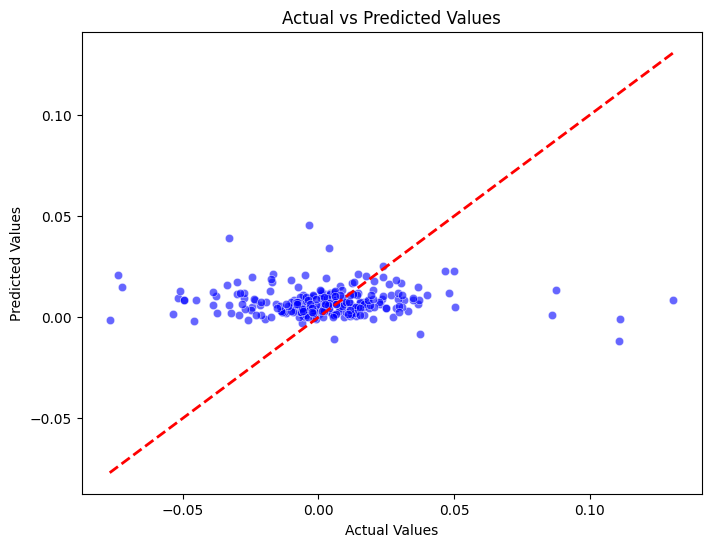

In [124]:
regression_knn_svm_pipeline = {
    'KNN': Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsRegressor())]),
    'SVM': Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR())])
}

# --------------------------
# Param Grids
# --------------------------
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

param_grid_svr = {
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto']
}

grids_knn_svm = {
    'KNN': GridSearchCV(regression_knn_svm_pipeline['KNN'], param_grid_knn, cv=5, scoring='r2'),
    'SVM': GridSearchCV(regression_knn_svm_pipeline['SVM'], param_grid_svr, cv=5, scoring='r2')
}

# --------------------------
# Fit & Evaluate
# --------------------------
for name, grid in grids_knn_svm.items():
    print(f"\n{name} Model")
    grid.fit(x_train, y_train)

    # Predictions
    y_pred = grid.predict(x_test)

    # Metrics
    rmse = mean_squared_error(y_test, y_pred)  # directly RMSE
    r2 = r2_score(y_test, y_pred)

    # Print results
    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    print(f"Test RMSE: {np.sqrt(rmse)}")
    print(f"Test R2: {r2}")
    print("="*60)
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # perfect fit line
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.show()

### Because of lack of good data the regression models is not very good

In [125]:
data.head()

,Date,Volume,year,month,day,target,Close_Return,Open_Return,High_Return,Low_Return,Volume_Return,Close_Lag1,Volatility_10d,Volume_Ratio_20d,RSI_14,MACD,Bollinger_Band_Width,Target_Return_next,Target_Dir_next,DayOfWeek
0,2020-10-05 09:30:00+05:30,4088100.0,2020,10,5,1,0.034966,-0.018647,-0.010221,-0.001989,-0.326641,503.059998,0.031177,0.753629,42.225641,-1.073194,0.128235,-0.028388,0,0
1,2020-10-06 09:30:00+05:30,4199000.0,2020,10,6,0,-0.028388,0.023520,0.001593,0.004903,0.027128,520.650024,0.030967,0.805107,48.423000,0.989208,0.131664,0.056912,1,1
2,2020-10-07 09:30:00+05:30,7988700.0,2020,10,7,1,0.056912,-0.001388,0.028113,0.023128,0.902524,505.869995,0.032924,1.552177,44.138658,1.414743,0.131185,-0.005368,0,2
3,2020-10-08 09:30:00+05:30,5386500.0,2020,10,8,0,-0.005368,0.029884,-0.002777,0.016149,-0.325735,534.659973,0.032638,1.035109,52.883571,4.028653,0.152950,0.014385,1,3
4,2020-10-09 09:30:00+05:30,4781300.0,2020,10,9,0,0.014385,0.008154,0.017346,0.020700,-0.112355,531.789978,0.033099,0.926408,52.009491,5.801733,0.166471,0.000686,1,4


In [126]:
X_classi = data.drop(['Target_Dir_next','Date','Target_Return_next','target'],axis=1)

In [127]:
y_classi = data['Target_Dir_next']

### Raw Models

In [128]:
from sklearn.metrics import roc_auc_score,roc_curve,auc

In [129]:
x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
sc = StandardScaler()
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

# Logistic Regression

accuracy :  0.4493927125506073
confusion matrix :  [[39 72]
 [64 72]]
Precision 0.5
recall :  0.5294117647058824
f1_score :  0.5142857142857142


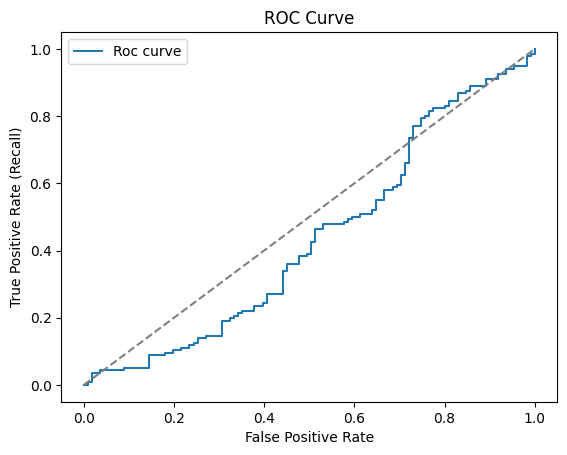

In [130]:
ll = LogisticRegression()
ll.fit(x_train_classi,y_train_classi)
y_pred_logistic = ll.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_logistic))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_logistic))
print("Precision" ,precision_score(y_test_classi,y_pred_logistic))
print("recall : ",recall_score(y_test_classi,y_pred_logistic))
print("f1_score : ",f1_score(y_test_classi,y_pred_logistic))

y_pred_logistic_proba = ll.predict_proba(x_test_classi)[:,1]
fpr ,tpr ,thresholds = roc_curve(y_test_classi,y_pred_logistic_proba)
plt.plot(fpr,tpr,label='Roc curve')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [131]:
roc_auc_socre_val = roc_auc_score(y_test_classi,y_pred_logistic_proba)
roc_auc_socre_val

0.43607578166401695

In [132]:
y_classi.value_counts()

Target_Dir_next
1    639
0    594
Name: count, dtype: int64

In [133]:
selected_columns

Index(['Volume', 'year', 'Close_Return', 'Open_Return', 'High_Return',
       'Low_Return', 'Volume_Return', 'Volume_Ratio_20d',
       'Bollinger_Band_Width', 'DayOfWeek'],
      dtype='object')

### Using the selected columns which have been we selected using RFE 

In [134]:
X_classi = data[selected_columns]

In [135]:
x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
sc = StandardScaler()
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

accuracy :  0.46963562753036436
confusion matrix :  [[37 74]
 [57 79]]
Precision 0.5163398692810458
recall :  0.5808823529411765
f1_score :  0.5467128027681661


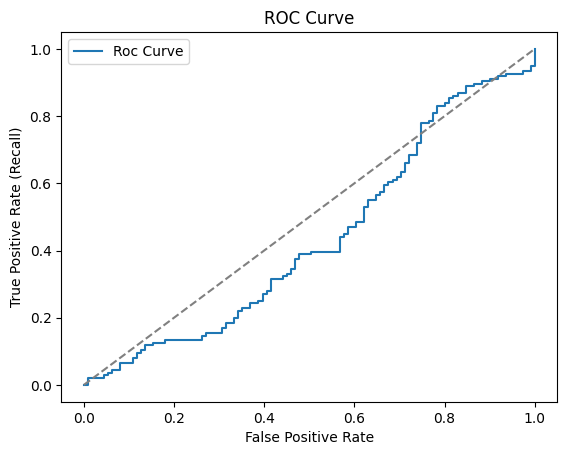

In [136]:
ll = LogisticRegression()
ll.fit(x_train_classi,y_train_classi)
y_pred_logistic = ll.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_logistic))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_logistic))
print("Precision" ,precision_score(y_test_classi,y_pred_logistic))
print("recall : ",recall_score(y_test_classi,y_pred_logistic))
print("f1_score : ",f1_score(y_test_classi,y_pred_logistic))

y_pred_logistic_proba = ll.predict_proba(x_test_classi)[:,1]
fpr, tpr,thresholds = roc_curve(y_test_classi,y_pred_logistic_proba)
plt.plot(fpr,tpr,label='Roc Curve')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [137]:
auc_logistic = auc(fpr,tpr)
auc_logistic

0.435214626391097

In [138]:
auc_roc_logistic = roc_auc_score(y_test_classi,y_pred_logistic)
auc_roc_logistic

0.45710784313725494

#### The selected coloumn is giving slightly better results

In [139]:
param_grid_logistic = {

    'C':[0.01,0.1,1.0,10.0],
    'max_iter':[1000,2000,10000],
    'solver': ['liblinear', 'saga','lbfgs'],
    'fit_intercept':[True,False]
}
logistic_grid = GridSearchCV(LogisticRegression(),param_grid_logistic,cv=5,scoring='accuracy')
logistic_grid.fit(x_train_classi,y_train_classi)
print("Best Params:", logistic_grid.best_params_)
print("Best CV Score:", logistic_grid.best_score_)
print("Test accuracy:", logistic_grid.score(x_test_classi, y_test_classi))



y_pred_logistic_hyper = logistic_grid.predict(x_test_classi)


print("accuracy : ",accuracy_score(y_test_classi,y_pred_logistic_hyper))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_logistic_hyper))
print("Precision" ,precision_score(y_test_classi,y_pred_logistic_hyper,average="binary"))
print("recall : ",recall_score(y_test_classi,y_pred_logistic_hyper,average="binary"))
print("f1_score : ",f1_score(y_test_classi,y_pred_logistic_hyper,average="binary"))

Best Params: {'C': 0.01, 'fit_intercept': True, 'max_iter': 1000, 'solver': 'saga'}
Best CV Score: 0.4878172588832488
Test accuracy: 0.4979757085020243
accuracy :  0.4979757085020243
confusion matrix :  [[28 83]
 [41 95]]
Precision 0.5337078651685393
recall :  0.6985294117647058
f1_score :  0.6050955414012739


### Feature Importance of Logistic Regression

In [140]:
best_model_logistic = logistic_grid.best_estimator_
coef_logistic= best_model_logistic.coef_[0]
features_logistic = x_train_classi.columns
feature_importance_logistic = pd.DataFrame({
    'Features':features_logistic,
    'coef':coef_logistic,
    'Absolute Importance':np.abs(coef_logistic)
}).sort_values(by='Absolute Importance',ascending=False)

feature_importance_logistic

,Features,coef,Absolute Importance
6,Volume_Return,-0.069700,0.069700
5,Low_Return,0.051989,0.051989
3,Open_Return,0.030015,0.030015
2,Close_Return,-0.021973,0.021973
8,Bollinger_Band_Width,0.015081,0.015081
9,DayOfWeek,-0.014345,0.014345
1,year,0.011325,0.011325
0,Volume,-0.007989,0.007989
4,High_Return,-0.007389,0.007389
7,Volume_Ratio_20d,-0.006544,0.006544


# Decision Tree Classifier

#### Using all the features

In [141]:
X_classi = data.drop(['Target_Dir_next','Date','Target_Return_next','target'],axis=1)


x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

accuracy :  0.5020242914979757
confusion matrix :  [[54 57]
 [66 70]]
Precision 0.5511811023622047
recall :  0.5147058823529411
f1_score :  0.532319391634981
Feature importance  [0.08783444 0.03735961 0.13530226 0.08062661 0.14403131 0.08130087
 0.10501298 0.14599799 0.12049629 0.06203764]


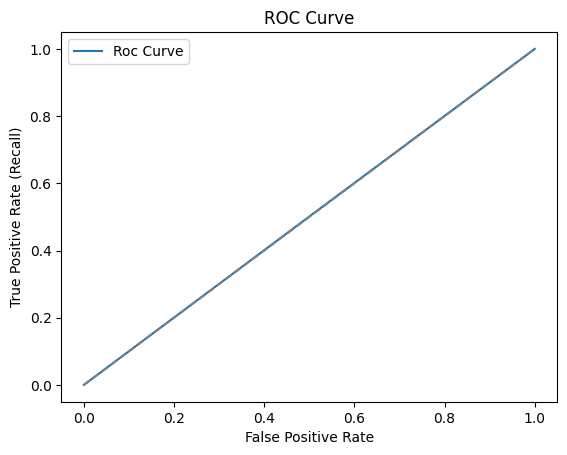

In [160]:
dc= DecisionTreeClassifier()
dc.fit(x_train_classi,y_train_classi)
y_pred_dc = dc.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_dc))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_dc))
print("Precision" ,precision_score(y_test_classi,y_pred_dc))
print("recall : ",recall_score(y_test_classi,y_pred_dc))
print("f1_score : ",f1_score(y_test_classi,y_pred_dc))
print("Feature importance ",dc.feature_importances_)
y_pred_decision_proba = dc.predict_proba(x_test_classi)[:,1]
fpr,tpr,thresholds = roc_curve(y_test_classi,y_pred_decision_proba)
plt.plot(fpr,tpr,label='Roc Curve')
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [143]:
roc_auc_socre_decision = roc_auc_score(y_test_classi,y_pred_decision_proba)
roc_auc_socre_decision

0.5438857975622682

### Using the selected features

In [144]:
X_classi = data[selected_columns]
x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

accuracy :  0.5060728744939271
confusion matrix :  [[52 59]
 [63 73]]
Precision 0.553030303030303
recall :  0.5367647058823529
f1_score :  0.5447761194029851


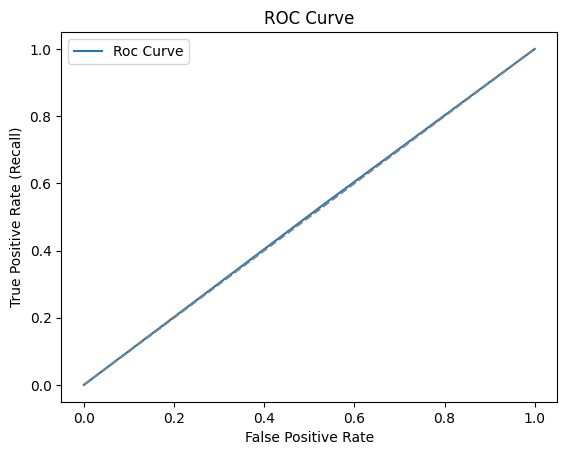

In [145]:
dc= DecisionTreeClassifier()
dc.fit(x_train_classi,y_train_classi)
y_pred_dc = dc.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_dc))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_dc))
print("Precision" ,precision_score(y_test_classi,y_pred_dc))
print("recall : ",recall_score(y_test_classi,y_pred_dc))
print("f1_score : ",f1_score(y_test_classi,y_pred_dc))

y_pred_decision_proba = dc.predict_proba(x_test_classi)[:,1]
fpr,tpr,thresholds = roc_curve(y_test_classi,y_pred_decision_proba)
plt.plot(fpr,tpr,label='Roc Curve')
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

### As we can see the performance decreased by using the selected features it is because Decision Tree Itself have a feature selection 

### Hyper Parameter Tuning

In [146]:
X_classi = data.drop(['Target_Dir_next','Date','Target_Return_next','target'],axis=1)


x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

In [147]:
param_grid_decision ={
    'criterion':['gini','entropy'],
    'max_depth':[None,1,10,20, 50],
    'min_samples_split':[2,3,4,5,6,10],
    'min_samples_leaf':[1,2,3,4],
    'max_leaf_nodes':[None,2,3]
}
decision_tree_grid =GridSearchCV(DecisionTreeClassifier(),param_grid_decision,cv=5,scoring='f1')
decision_tree_grid.fit(x_train_classi,y_train_classi)
y_pred_dc = decision_tree_grid.predict(x_test_classi)
# Best Parameters
print("Best Params:", decision_tree_grid.best_params_)
print("Best CV Score:", decision_tree_grid.best_score_)
print("Test f1:", decision_tree_grid.score(x_test_classi, y_test_classi))

# Evaluation Metrics
print("accuracy : ",accuracy_score(y_test_classi,y_pred_dc))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_dc))
print("Precision" ,precision_score(y_test_classi,y_pred_dc,average="binary"))
print("recall : ",recall_score(y_test_classi,y_pred_dc,average="binary"))
print("f1_score : ",f1_score(y_test_classi,y_pred_dc,average="binary"))

Best Params: {'criterion': 'entropy', 'max_depth': None, 'max_leaf_nodes': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.676106553191884
Test f1: 0.7105263157894737
accuracy :  0.5546558704453441
confusion matrix :  [[  2 109]
 [  1 135]]
Precision 0.5532786885245902
recall :  0.9926470588235294
f1_score :  0.7105263157894737


### From raw 

Accuracy ≈ 54% : close to random guessing.

F1-score ≈ 0.58 : weak balance between precision & recall.

Confusion matrix : model makes balanced mistakes (misses both up & down).

Insight: Does not capture useful stock patterns : not reliable.

### Tuned Decision Tree
Accuracy ≈ 55% : small improvement.

Recall ≈ 99% → catches almost all “up” movements.

Precision dropped : many false “buy” signals.

Confusion matrix : predicts “UP” most of the time, misses “DOWN.”

Insight: High recall but low precision : looks impressive on paper, but risky in trading.

### other 

Markets are noisy and imbalanced (more small UP moves).

Model biased toward UP prediction : may catch rallies but fails on downturns.

Traders usually prefer precision (fewer false signals) or a balance, not just recall.

Insight: Model isn’t trade-ready : needs better features, ensemble methods, or financial evaluation (profit/loss simulation).


# SVM

### Using all features

In [148]:
X_classi = data.drop(['Target_Dir_next','Date','Target_Return_next','target'],axis=1)


x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
sc = StandardScaler()
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

accuracy :  0.5668016194331984
confusion matrix :  [[43 68]
 [39 97]]
Precision 0.5878787878787879
recall :  0.7132352941176471
f1_score :  0.6445182724252492


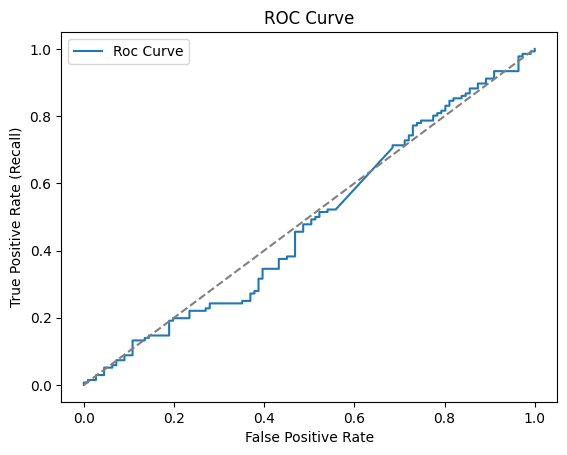

In [149]:
svm= SVC(probability=True)
svm.fit(x_train_classi,y_train_classi)
y_pred_svm = svm.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_svm))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_svm))
print("Precision" ,precision_score(y_test_classi,y_pred_svm))
print("recall : ",recall_score(y_test_classi,y_pred_svm))
print("f1_score : ",f1_score(y_test_classi,y_pred_svm))
y_pred_svm_proba = svm.predict_proba(x_test_classi)[:,1]
fpr,tpr,thresholds = roc_curve(y_test_classi,y_pred_svm_proba)
plt.plot(fpr,tpr,label='Roc Curve')
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [150]:
auc_roc_svm = roc_auc_score(y_test_classi,y_pred_svm_proba)
auc_roc_svm

0.48350556438791736

### After using the selected features

In [151]:
X_classi = data[selected_columns]


x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
sc = StandardScaler()
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

accuracy :  0.4939271255060729
confusion matrix :  [[40 71]
 [54 82]]
Precision 0.5359477124183006
recall :  0.6029411764705882
f1_score :  0.5674740484429066


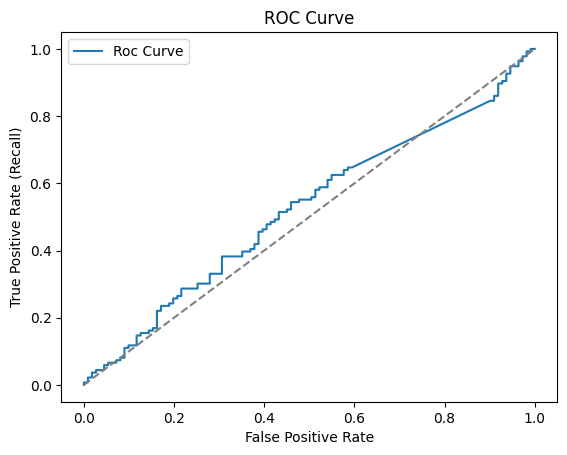

In [152]:
svm= SVC(probability=True)
svm.fit(x_train_classi,y_train_classi)
y_pred_svm = svm.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_svm))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_svm))
print("Precision" ,precision_score(y_test_classi,y_pred_svm))
print("recall : ",recall_score(y_test_classi,y_pred_svm))
print("f1_score : ",f1_score(y_test_classi,y_pred_svm))

y_pred_svm_proba = svm.predict_proba(x_test_classi)[:,1]
fpr,tpr,thresholds = roc_curve(y_test_classi,y_pred_svm_proba)
plt.plot(fpr,tpr,label='Roc Curve')
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Hyper Parameter Tuning

In [153]:
param_grid_svm={
    'C':[0.01,1,10],
    'kernel':['rbf','linear','poly'],
    'degree':[2,3,4],
    'probability':[True,False],
    'gamma':['scale','auto']

}
svm_grid = GridSearchCV(SVC(),param_grid_svm,cv=5,scoring='f1')
svm_grid.fit(x_train_classi,y_train_classi)
y_pred_svm = svm_grid.predict(x_test_classi)
# Best Parameters
print("Best Params:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)
print("Test f1:", svm_grid.score(x_test_classi, y_test_classi))

# Evaluation Metrics
print("accuracy : ",accuracy_score(y_test_classi,y_pred_svm))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_svm))
print("Precision" ,precision_score(y_test_classi,y_pred_svm,average="binary"))
print("recall : ",recall_score(y_test_classi,y_pred_svm,average="binary"))
print("f1_score : ",f1_score(y_test_classi,y_pred_svm,average="binary"))

Best Params: {'C': 0.01, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly', 'probability': True}
Best CV Score: 0.6792750681914924
Test f1: 0.7068062827225131
accuracy :  0.5465587044534413
confusion matrix :  [[  0 111]
 [  1 135]]
Precision 0.5487804878048781
recall :  0.9926470588235294
f1_score :  0.7068062827225131


### Insights
Raw SVM: More balanced between precision and recall, but weaker F1.

Tuned SVM: Strong recall (good for not missing positive signals), higher F1, but poor precision → not reliable if you care about minimizing false alarms.

For stock prediction, this means:

If your strategy values catching every upward movement (high recall), tuned SVM is better.

If your strategy values avoiding false signals (high precision), raw SVM might be safer.

# KNN

### Using all features

In [154]:
X_classi = data.drop(['Target_Dir_next','Date','Target_Return_next','target'],axis=1)


x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
sc = StandardScaler()
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

accuracy :  0.5182186234817814
confusion matrix :  [[55 56]
 [63 73]]
Precision 0.5658914728682171
recall :  0.5367647058823529
f1_score :  0.5509433962264151


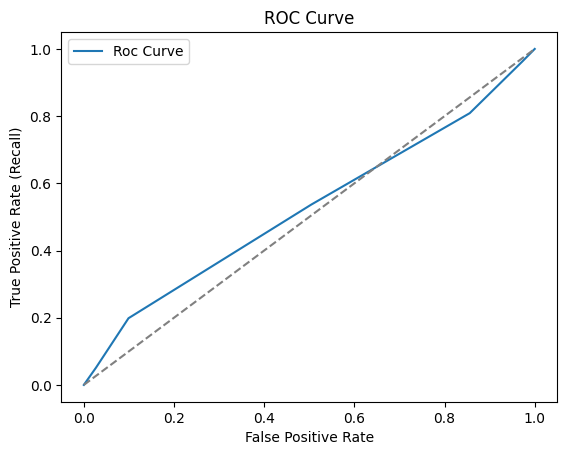

In [155]:
knn= KNeighborsClassifier()
knn.fit(x_train_classi,y_train_classi)
y_pred_knn = knn.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_knn))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_knn))
print("Precision" ,precision_score(y_test_classi,y_pred_knn))
print("recall : ",recall_score(y_test_classi,y_pred_knn))
print("f1_score : ",f1_score(y_test_classi,y_pred_knn))

y_pred_knn_proba = knn.predict_proba(x_test_classi)[:,1]
fpr,tpr,thresholds = roc_curve(y_test_classi,y_pred_knn_proba)
plt.plot(fpr,tpr,label='Roc Curve')
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [156]:
auc_roc_knn = roc_auc_score(y_test_classi,y_pred_knn_proba)
auc_roc_knn

0.5254372019077902

### After using the selected features


In [157]:
X_classi = data[selected_columns]


x_train_classi,x_test_classi,y_train_classi,y_test_classi= train_test_split(X_classi,y_classi,test_size=0.2,random_state=42)
sc = StandardScaler()
x_train_classi = pd.DataFrame(sc.fit_transform(x_train_classi),columns=X_classi.columns,index=x_train_classi.index)
x_test_classi = pd.DataFrame(sc.transform(x_test_classi),columns=X_classi.columns,index=x_test_classi.index)

accuracy :  0.5668016194331984
confusion matrix :  [[57 54]
 [53 83]]
Precision 0.6058394160583942
recall :  0.6102941176470589
f1_score :  0.608058608058608


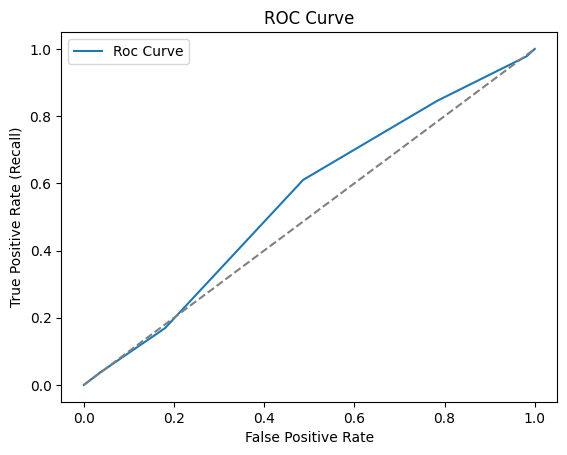

In [158]:
knn= KNeighborsClassifier()
knn.fit(x_train_classi,y_train_classi)
y_pred_knn = knn.predict(x_test_classi)

print("accuracy : ",accuracy_score(y_test_classi,y_pred_knn))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_knn))
print("Precision" ,precision_score(y_test_classi,y_pred_knn))
print("recall : ",recall_score(y_test_classi,y_pred_knn))
print("f1_score : ",f1_score(y_test_classi,y_pred_knn))

y_pred_knn_proba = knn.predict_proba(x_test_classi)[:,1]
fpr,tpr,thresholds = roc_curve(y_test_classi,y_pred_knn_proba)
plt.plot(fpr,tpr,label='Roc Curve')
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Here selected features gives us better results

### Hyper parameter tuning

In [159]:
param_grid_knn={
    'n_neighbors':[2,4,3,5,6],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan','minkowski']
}
knn_grid = GridSearchCV(KNeighborsClassifier(),param_grid_knn,cv=5,scoring='f1')
knn_grid.fit(x_train_classi,y_train_classi)
y_pred_knn = knn_grid.predict(x_test_classi)
# Best Parameters
print("Best Params:", knn_grid.best_params_)
print("Best CV Score:", knn_grid.best_score_)
print("Test f1:", knn_grid.score(x_test_classi, y_test_classi))

# Evaluation Metrics
print("accuracy : ",accuracy_score(y_test_classi,y_pred_knn))
print("confusion matrix : ",confusion_matrix(y_test_classi,y_pred_knn))
print("Precision" ,precision_score(y_test_classi,y_pred_knn,average="binary"))
print("recall : ",recall_score(y_test_classi,y_pred_knn,average="binary"))
print("f1_score : ",f1_score(y_test_classi,y_pred_knn,average="binary"))

Best Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV Score: 0.5442300490211622
Test f1: 0.608058608058608
accuracy :  0.5668016194331984
confusion matrix :  [[57 54]
 [53 83]]
Precision 0.6058394160583942
recall :  0.6102941176470589
f1_score :  0.608058608058608


### Insights 
Tuning didn’t improve results → likely because the hyperparameter search space was small or KNN itself isn’t capturing complex patterns in your stock dataset.

KNN may not be the best choice here since it relies heavily on local similarity, and stock price data is noisy + high variance.